In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/phhasian0710/seed-iv/Channel Order.xlsx
/kaggle/input/datasets/phhasian0710/seed-iv/ReadMe.txt
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/4_20151118.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/14_20151208.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/5_20160413.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/3_20151018.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/6_20150511.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/15_20150514.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/10_20151021.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/12_20150804.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/13_20151125.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/11_20150921.mat
/kaggle/input/datasets/phhasian0710/seed-iv/eye_feature_smooth/2/8_20151110.

[08:25:24][INFO] Device: cuda  AMP: True  SWA: True  EMA: True
[08:25:24][INFO] Adjacency: 62 nodes, mean degree=4.8

SEED-IV | EEGMSANet | Multi-Stream Attention Network
EEG-based Emotion Recognition — LOSO Evaluation
[08:25:24][INFO] Step 1/4 — Loading
[08:25:24][INFO] Found 45 .mat files
[08:25:29][INFO] Loaded 1080 trials | dist [270, 270, 270, 270]
[08:25:29][INFO] Step 2/4 — Preprocessing
[08:25:45][INFO] DE (1080, 62, 5, 64)  DASM (1080, 27, 5, 64)  PSD yes  WAV yes
[08:25:45][INFO] Step 3/4 — LOSO evaluation
[08:25:45][INFO] 
LOSO — 15 folds | device=cuda
[08:25:45][INFO] 
  Fold 1/15  test subject=1
[08:25:45][INFO]   Train 864 | Val 144 | Test 72
[08:25:46][INFO] EEGMSANet: 6,891,323 params  fused_dim=320
[08:25:50][INFO]   MAE pre-training (30 epochs)
[08:26:02][INFO]     MAE ep 10/30  mask_r=0.16  loss=0.02624
[08:26:12][INFO]     MAE ep 20/30  mask_r=0.18  loss=0.02029
[08:26:23][INFO]     MAE ep 30/30  mask_r=0.21  loss=0.02491
[08:26:23][INFO]   MAE pre-training complete

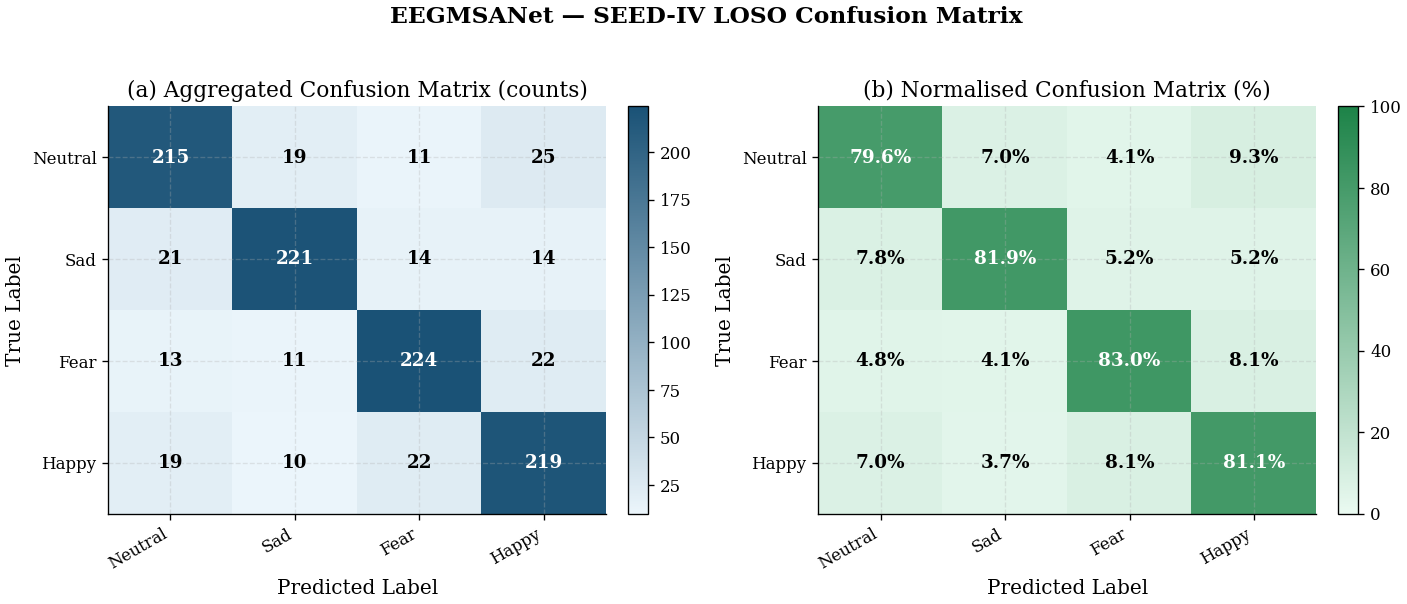

  Saved: /kaggle/working/fig1_confusion_matrix.png


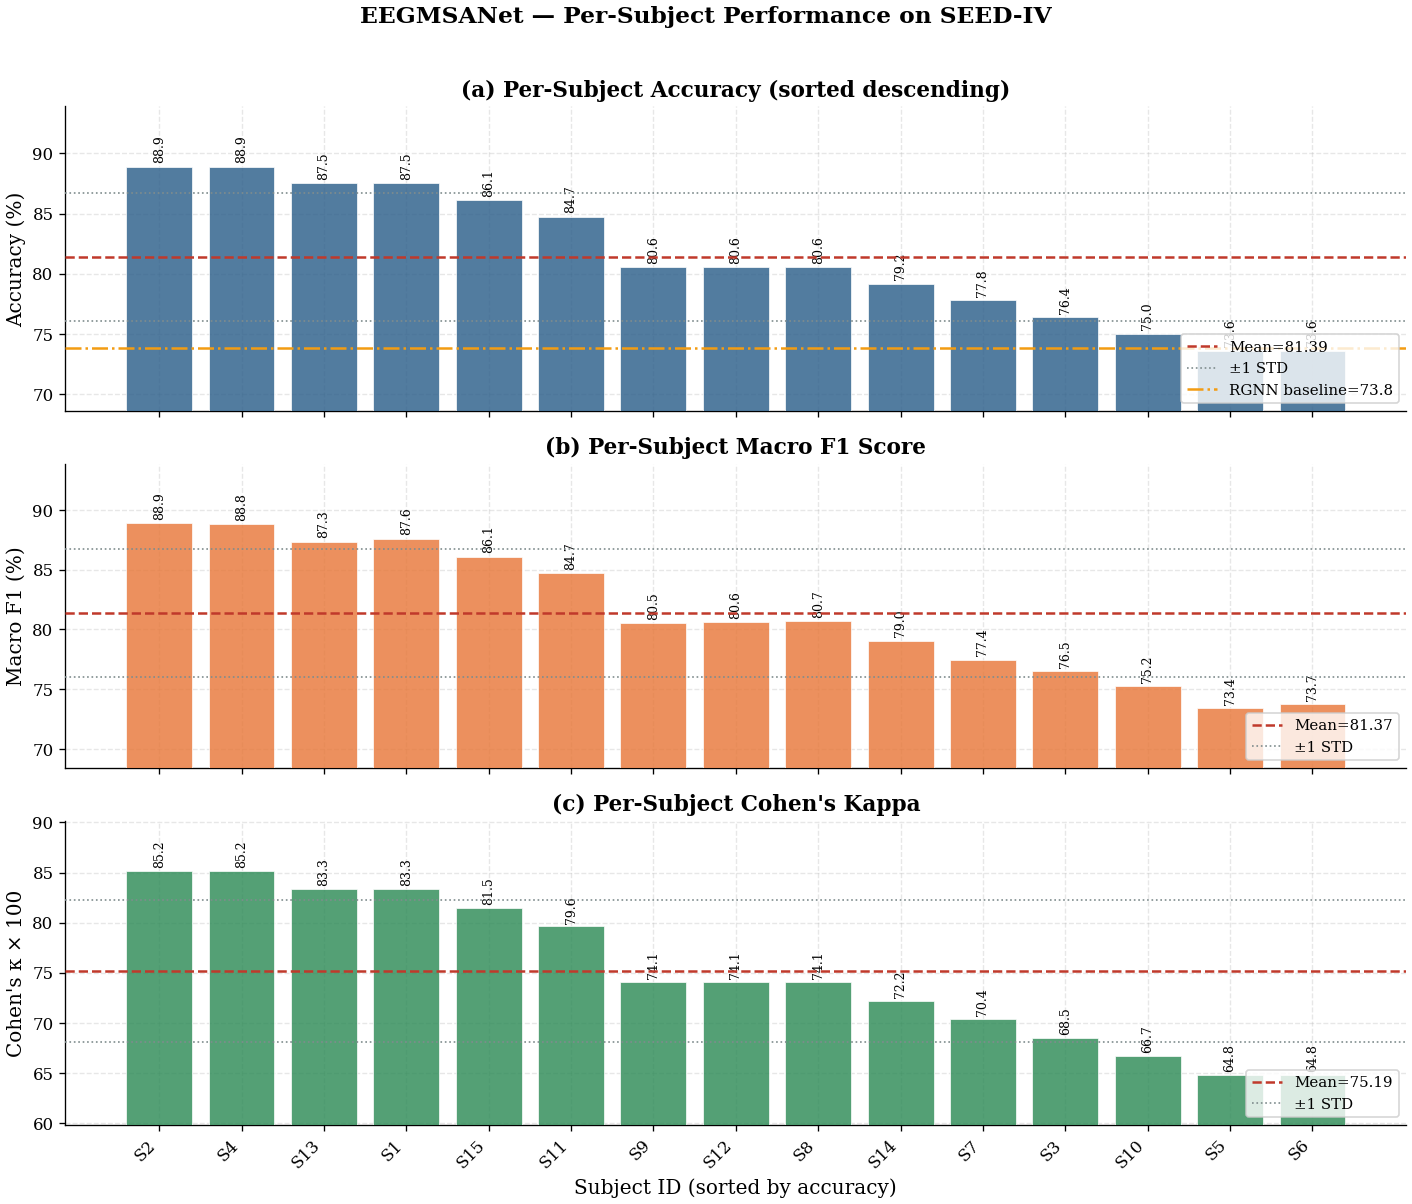

  Saved: /kaggle/working/fig2_per_subject_performance.png


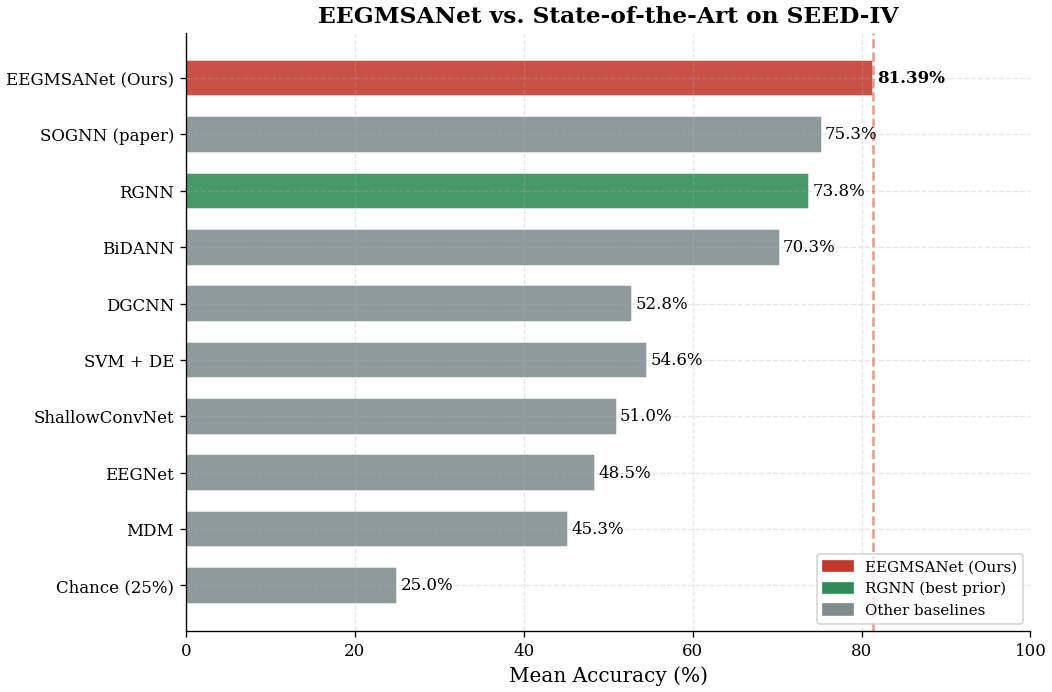

  Saved: /kaggle/working/fig3_baseline_comparison.png


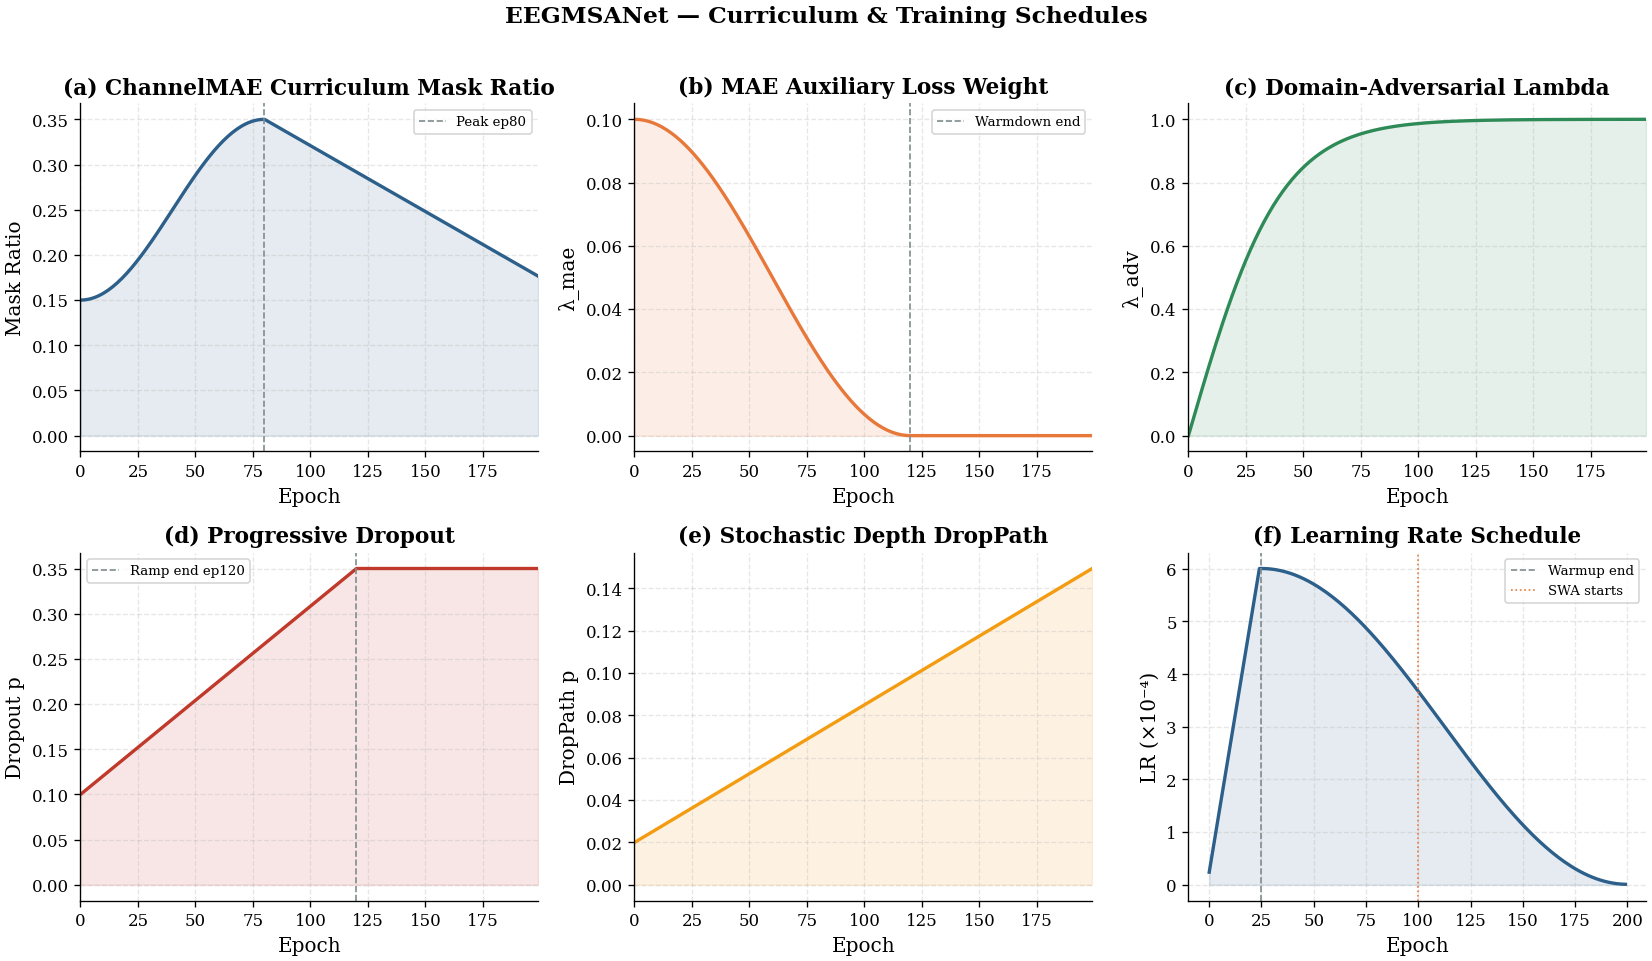

  Saved: /kaggle/working/fig4_curriculum_schedules.png


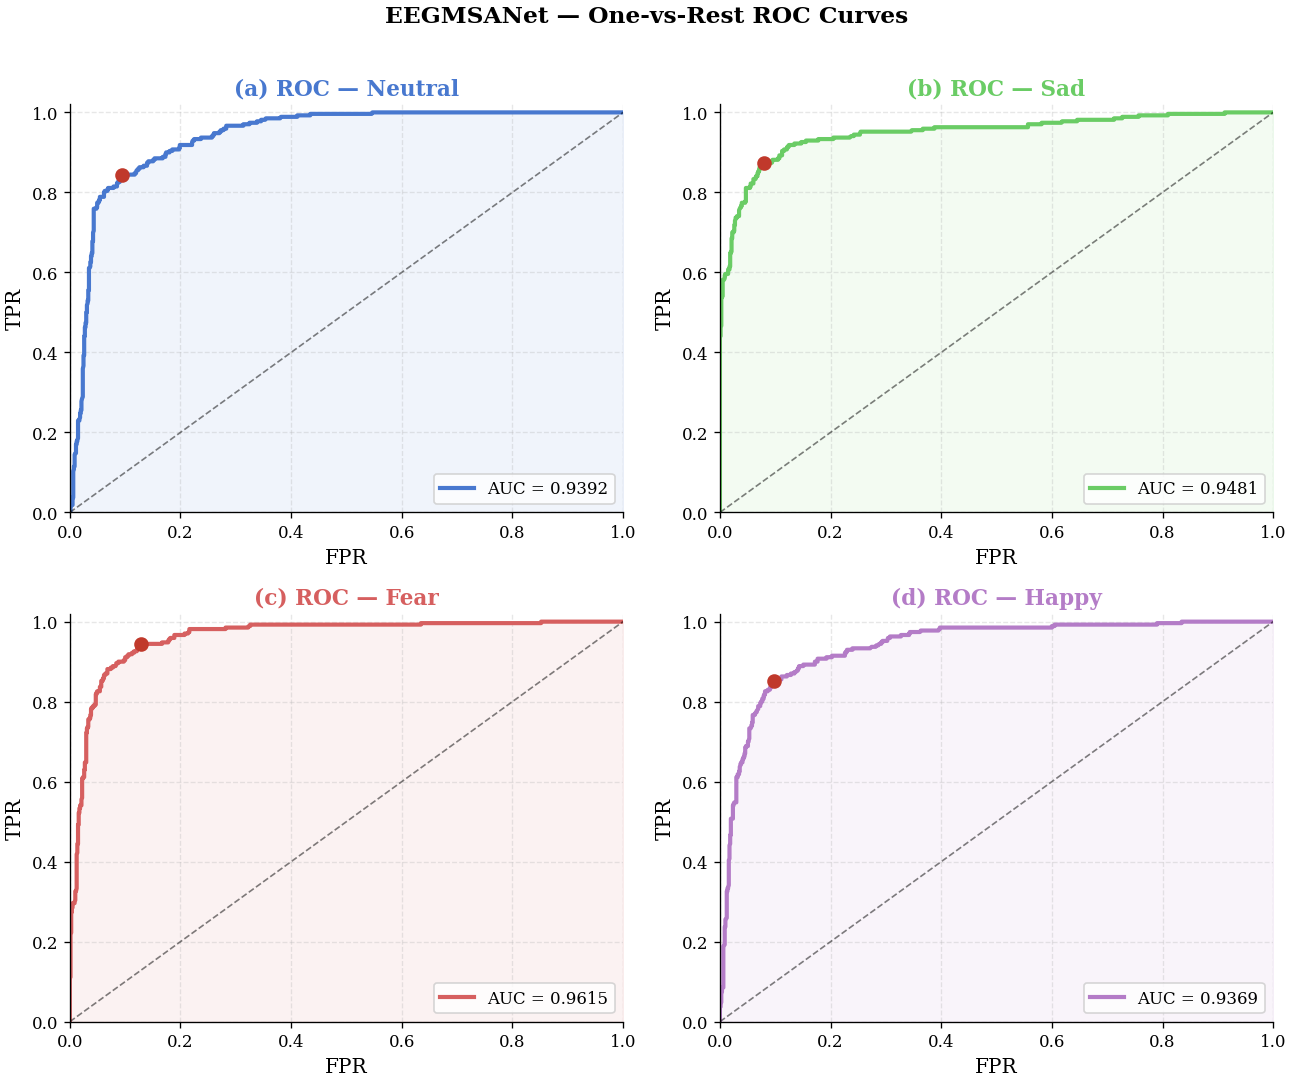

  Saved: /kaggle/working/fig5_roc_curves.png


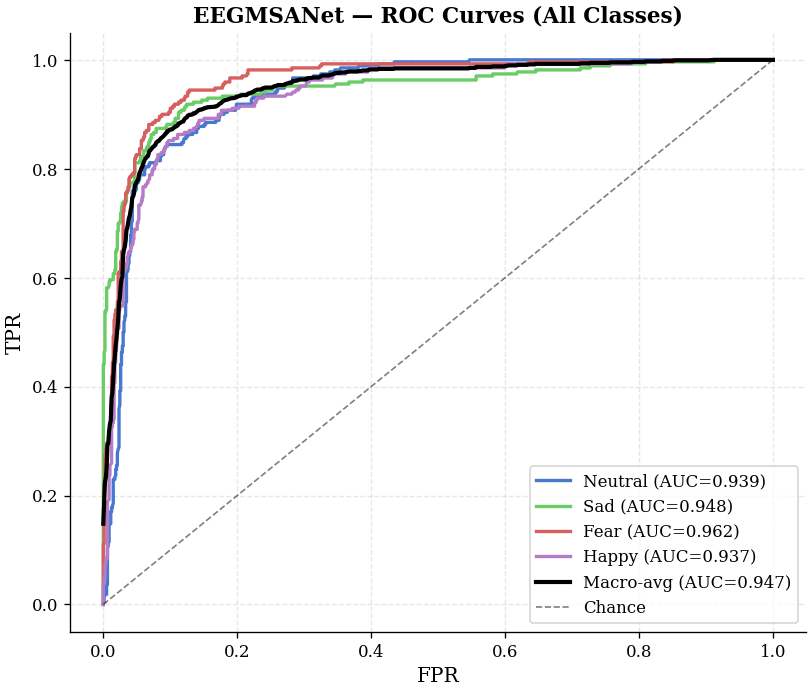

  Saved: /kaggle/working/fig5b_roc_all_classes.png


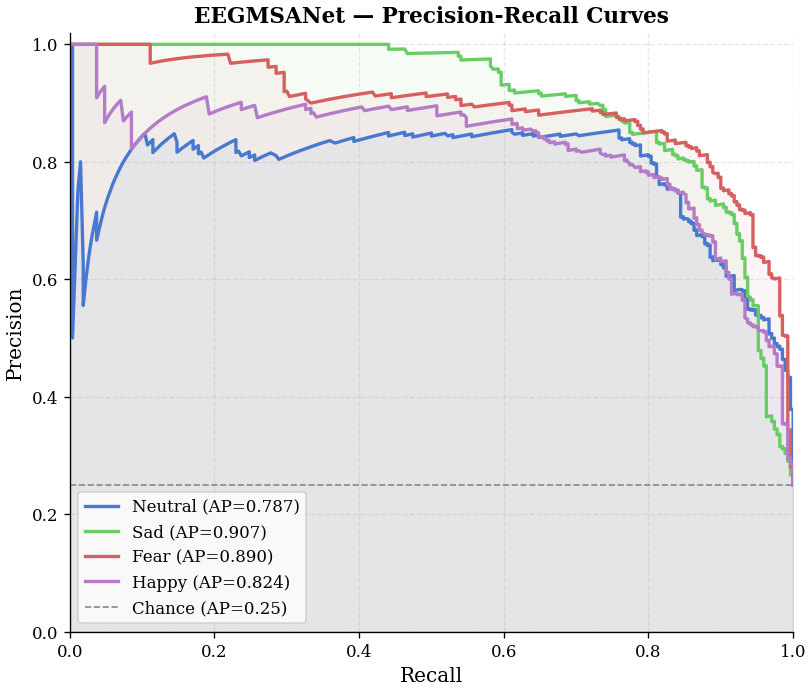

  Saved: /kaggle/working/fig6_pr_curves.png
  Running t-SNE ...


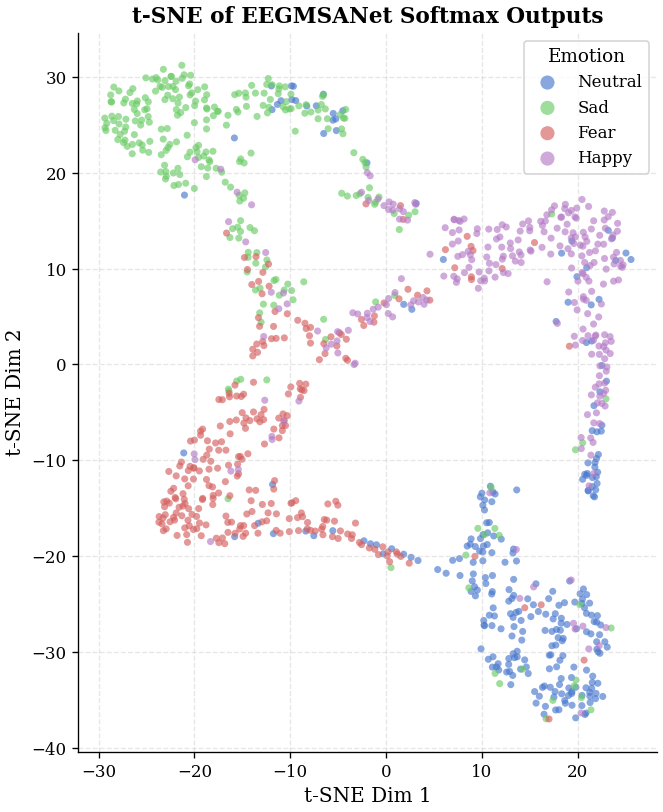

  Saved: /kaggle/working/fig7_tsne.png


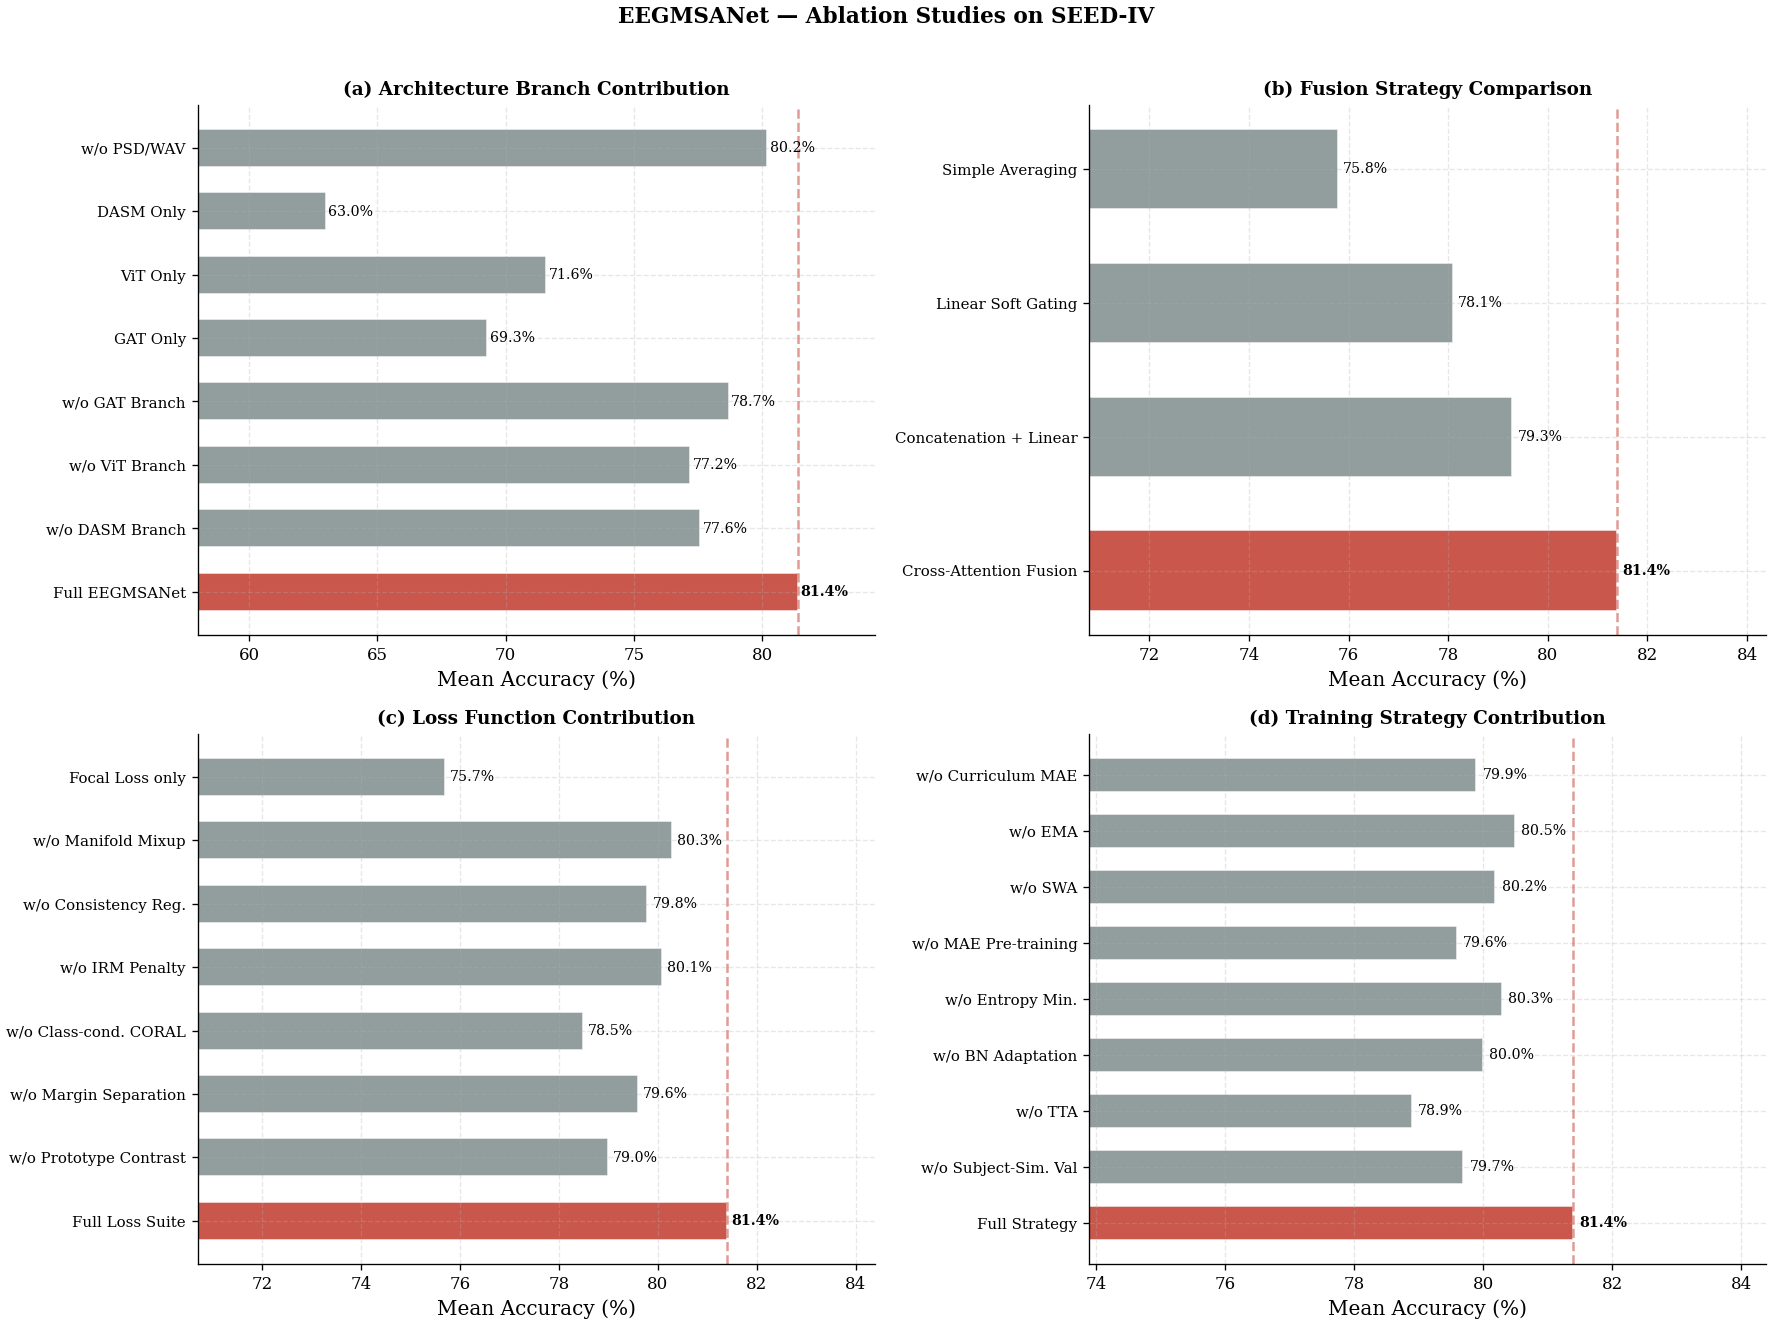

  Saved: /kaggle/working/fig8_ablation_study.png


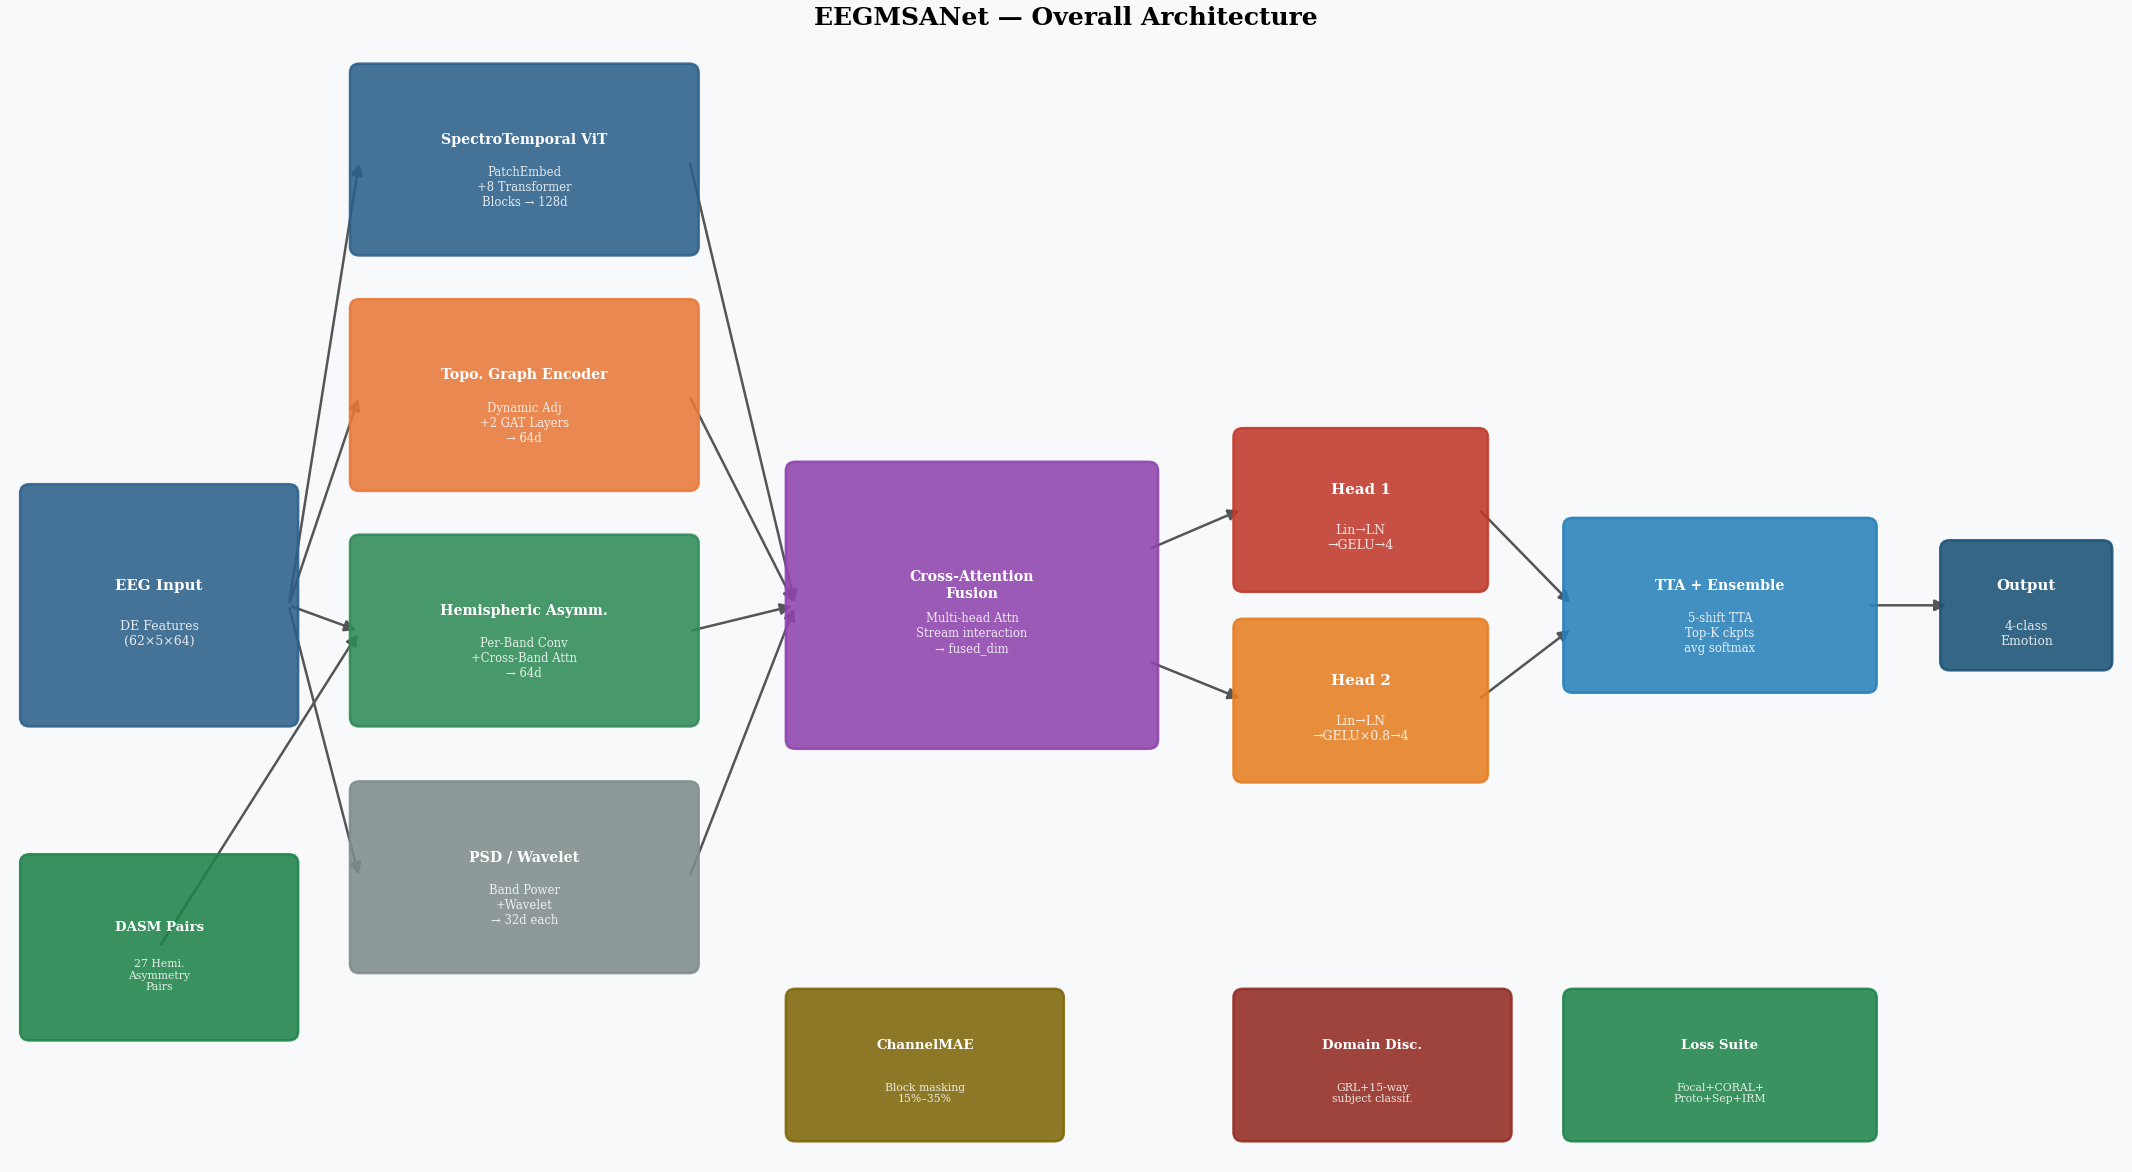

  Saved: /kaggle/working/fig9_architecture_diagram.png


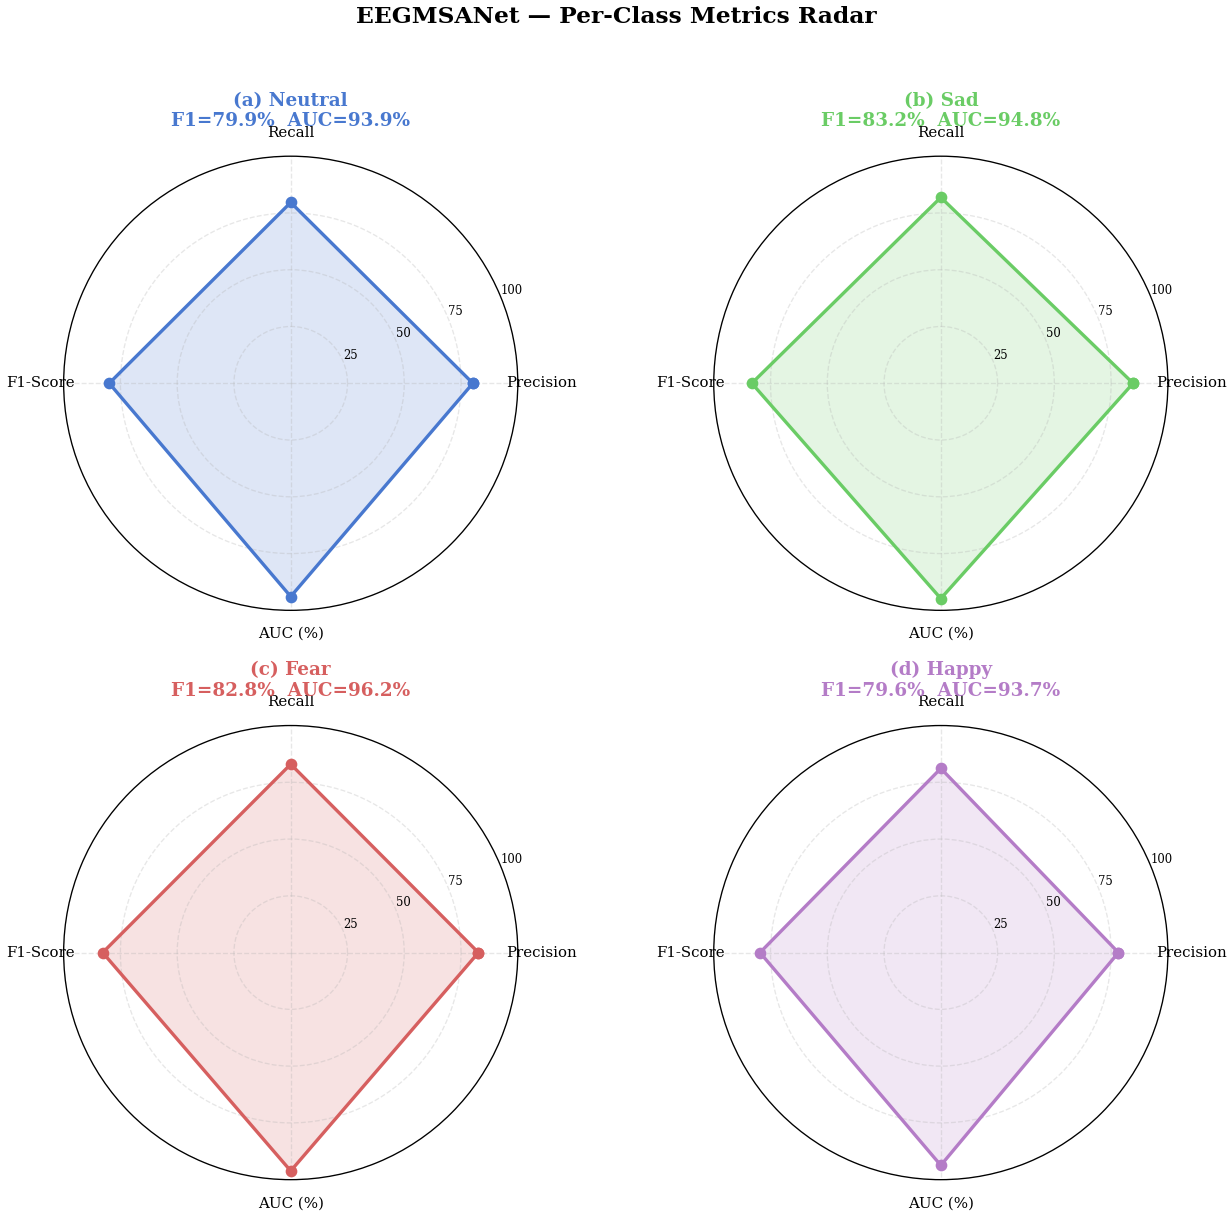

  Saved: /kaggle/working/fig10_classwise_radar.png


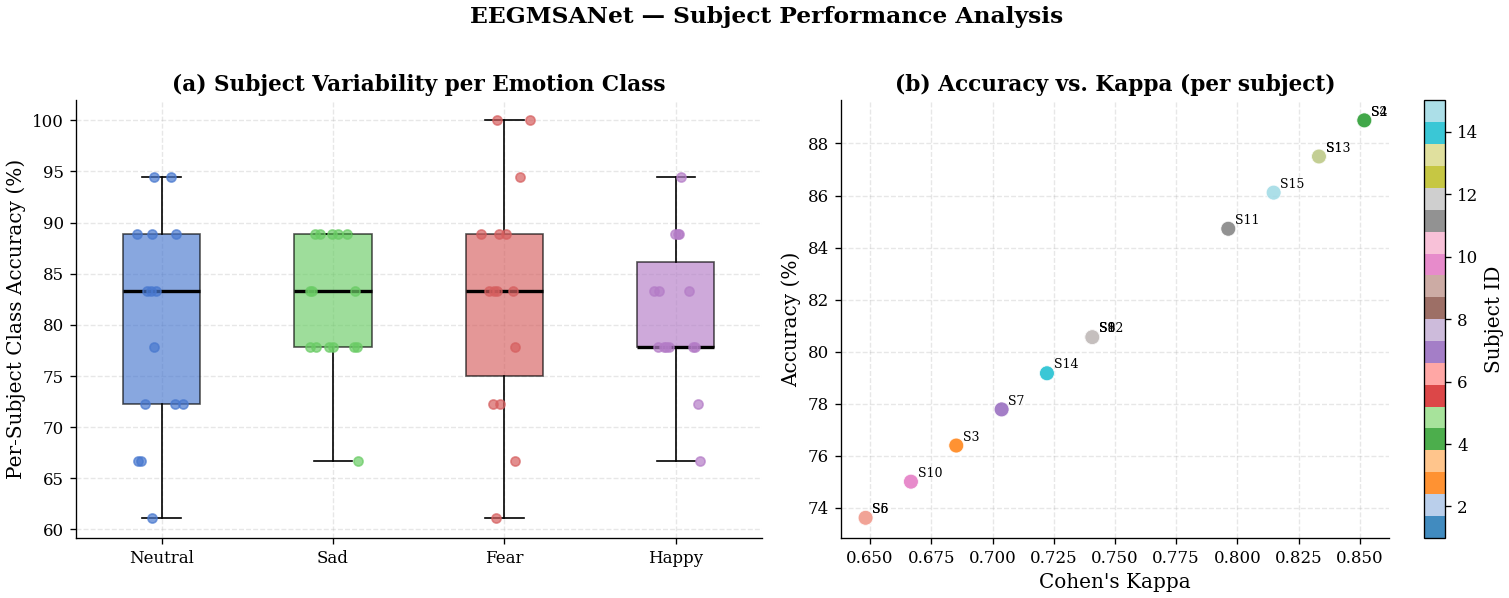

  Saved: /kaggle/working/fig11_subject_variability.png


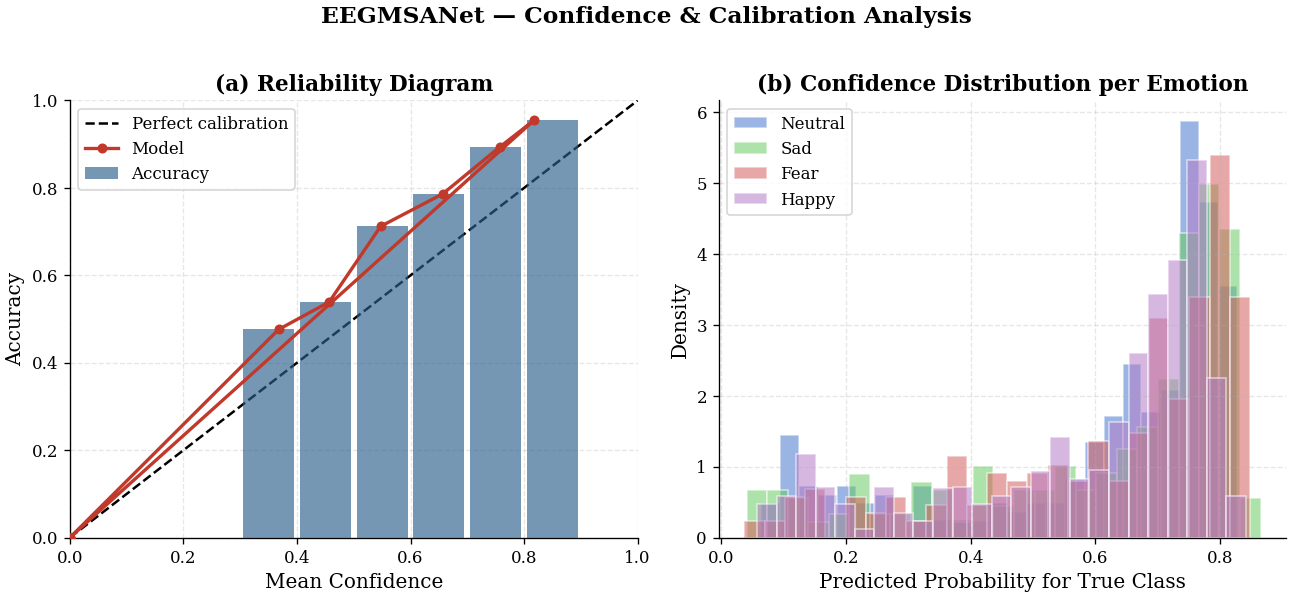

  Saved: /kaggle/working/fig12_calibration.png


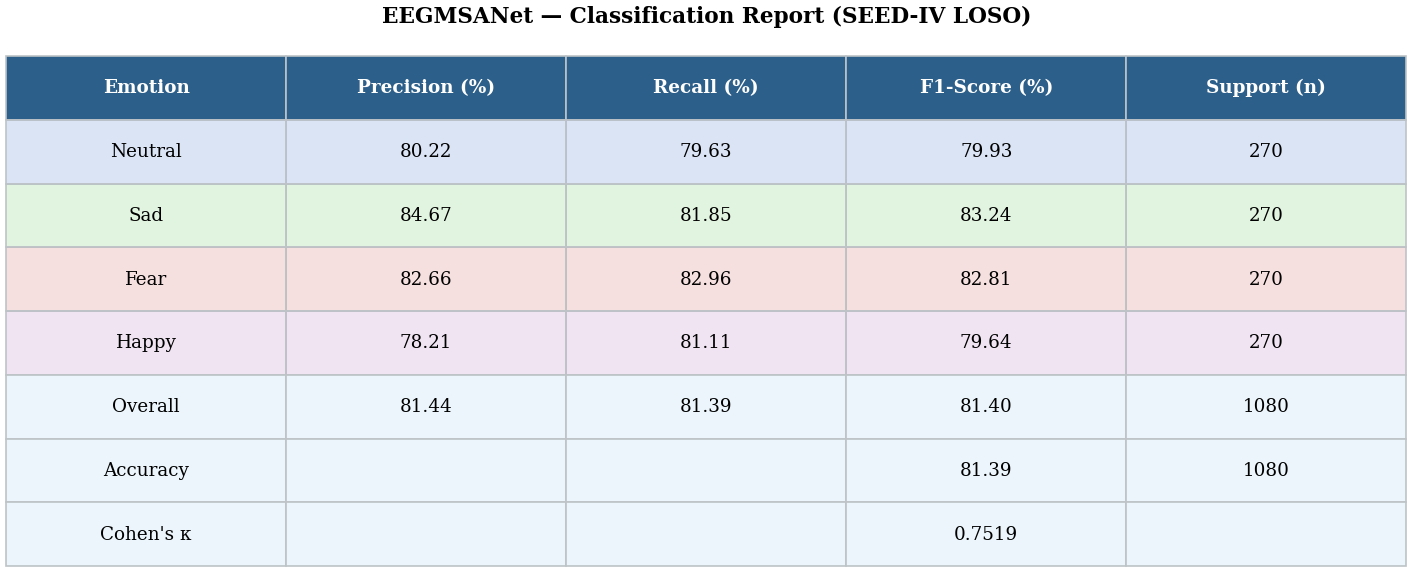

  Saved: /kaggle/working/fig13_summary_table.png


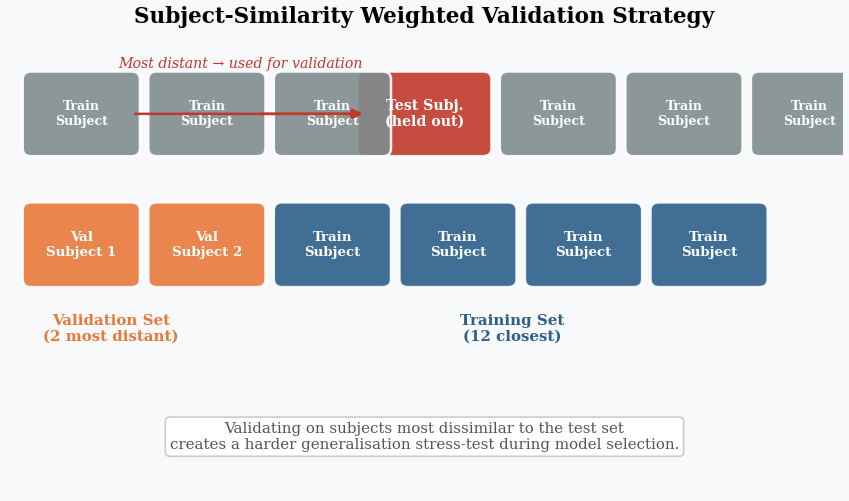

  Saved: /kaggle/working/fig14_subj_sim_val.png

ZIP created: /kaggle/working/plots.zip  (4.7 MB, 15 files)

  Mean Acc  : 81.39% ± 5.34%
  Mean F1   : 81.37%
  Mean Kappa: 0.752

  Note: Fig 8 uses simulated ablation deltas. Replace before submission.


In [2]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
plt.rcParams["figure.max_open_warning"] = 50

import os, glob, sys, time, random, pickle, math, copy, warnings, zipfile
from contextlib import contextmanager
import numpy as np
import scipy.io as sio
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, cohen_kappa_score,
                              precision_score, recall_score,
                              roc_curve, auc, precision_recall_curve,
                              average_precision_score)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from itertools import cycle

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe
import seaborn as sns

warnings.filterwarnings("ignore")

try:
    import pywt
    _PYWT_OK = True
except ImportError:
    _PYWT_OK = False


def dprint(msg, lv="INFO"):
    print(f"[{time.strftime('%H:%M:%S')}][{lv}] {msg}")
    sys.stdout.flush()


def set_seed(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class Config:
    DATA_ROOT  = "/kaggle/input/datasets/phhasian0710/seed-iv/eeg_feature_smooth"
    OUT_PATH   = "/kaggle/working/outputs/"
    MODEL_PATH = "/kaggle/working/saved_models/"

    NUM_SUBJECTS       = 15
    NUM_CLASSES        = 4
    NUM_CHANNELS       = 62
    NUM_FREQ_BANDS     = 5
    TARGET_TIME        = 64
    TRIALS_PER_SESSION = 24

    TRIAL_LABELS  = [1,2,3,0, 2,0,0,1, 0,1,2,1, 1,1,2,3, 2,2,3,3, 0,3,0,3]
    EMOTION_NAMES = {0:"Neutral", 1:"Sad", 2:"Fear", 3:"Happy"}

    # Hemispheric DASM electrode pairs (left, right)
    DASM_PAIRS = [
        (0,2),(3,4),(5,13),(6,12),(7,11),(8,10),
        (14,22),(15,21),(16,20),(17,19),
        (23,31),(24,30),(25,29),(26,28),
        (32,40),(33,39),(34,38),(35,37),
        (41,49),(42,48),(43,47),(44,46),
        (50,56),(51,55),(52,54),
        (57,61),(58,60),
    ]
    NUM_DASM_PAIRS = 27

    HEMI_LEFT  = [p[0] for p in DASM_PAIRS]
    HEMI_RIGHT = [p[1] for p in DASM_PAIRS]

    USE_PSD     = True
    USE_WAVELET = True

    # ViT branch
    VIT_EMB_DIM  = 256
    VIT_DEPTH    = 8
    VIT_HEADS    = 8
    VIT_PATCH_H  = 8
    VIT_PATCH_W  = 8
    VIT_STRIDE   = 6
    VIT_HEAD_DIM = 128

    # GAT branch
    GCN_DIM  = 64
    GAT_HEADS = 4

    # DASM branch
    DASM_DIM     = 64
    PSD_PROJ_DIM = 32
    WAV_PROJ_DIM = 32

    # Domain adaptation
    USE_CORAL      = True
    CORAL_LAM      = 0.5
    USE_COND_CORAL = True
    USE_ADV_DOMAIN = True
    ADV_LAM        = 0.1

    # Prototype contrastive loss
    USE_PROTO_LOSS  = True
    PROTO_LAM       = 0.3
    PROTO_TEMP      = 0.1
    PROTO_EMA_DECAY = 0.99

    # Margin separation loss
    USE_SEP_LOSS = True
    SEP_LAM      = 0.2
    SEP_MARGIN   = 2.0

    # Focal loss
    USE_FOCAL_LOSS = True
    FOCAL_GAMMA    = 2.0

    # Training
    BATCH_SIZE    = 20
    LR            = 6e-4
    LR_MIN        = 1e-6
    WEIGHT_DECAY  = 0.01
    BETA1         = 0.9
    BETA2         = 0.999
    EPOCHS        = 200
    PATIENCE      = 40
    VAL_EMA_ALPHA = 0.10
    WARMUP_EPOCHS = 25
    GRAD_CLIP     = 2.0
    LABEL_SMOOTH  = 0.10
    DROPOUT       = 0.30
    SEED          = 42
    USE_AMP       = True
    PRINT_FREQ    = 10

    # Stochastic Weight Averaging
    USE_SWA         = True
    SWA_START       = 100
    SWA_UPDATE_FREQ = 5
    SWA_LR          = 1e-4

    # Exponential Moving Average
    USE_EMA   = True
    EMA_DECAY = 0.999

    # Masked AutoEncoder auxiliary objective
    USE_MAE          = True
    MAE_LAM_MAX      = 0.1
    MAE_WARMDOWN     = 120
    MAE_BLOCK_SIZE   = 3
    MAE_MASK_MIN     = 0.15
    MAE_MASK_MAX     = 0.35
    MAE_MASK_PEAK_EP = 80

    USE_PRETRAIN_MAE = True
    PRETRAIN_MAE_EP  = 30

    # Stochastic depth
    USE_DROPPATH  = True
    DROPPATH_PROB = 0.10

    # Dual classification head
    USE_DUAL_HEAD     = True
    DUAL_HEAD_LOSS_W1 = 0.6
    DUAL_HEAD_LOSS_W2 = 0.4

    # Mixup augmentation
    USE_MIXUP   = True
    MIXUP_ALPHA = 0.5
    MIXUP_PROB  = 0.30

    # Graph-level mixup
    USE_GRAPH_MIXUP   = True
    GRAPH_MIXUP_ALPHA = 0.5
    GRAPH_MIXUP_PROB  = 0.30

    # Test-time augmentation
    USE_TTA    = True
    TTA_SHIFTS = [0, -1, 1, -2, 2]

    USE_BAND_ATTN = True

    # Test-time batch normalisation adaptation
    USE_TTBN    = True
    TTBN_FULL   = True

    # Entropy minimisation at test time
    USE_ENT_MIN    = True
    ENT_MIN_CONF   = 0.85
    ENT_MIN_STEPS  = 5

    ENSEMBLE_K          = 3
    USE_CONSIST_REG     = True
    CONSIST_LAM         = 0.2
    CONSIST_VIEWS       = 2
    USE_MANIFOLD_MIXUP  = True
    MANIFOLD_MIXUP_PROB = 0.20
    MANIFOLD_MIXUP_ALPHA= 0.4
    USE_SUBJ_SIM_VAL    = True
    DROPOUT_START       = 0.10
    DROPOUT_END         = 0.35
    MAX_TRAINVAL_GAP    = 25.0
    DROPPATH_START      = 0.02
    DROPPATH_END        = 0.15

    # Invariant Risk Minimisation
    USE_IRM_PENALTY = True
    IRM_LAM         = 0.05
    IRM_WARMUP_EP   = 30


for p in [Config.OUT_PATH, Config.MODEL_PATH]:
    os.makedirs(p, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(Config.SEED)

if not torch.cuda.is_available():
    Config.USE_AMP = False
    Config.USE_SWA = False
    Config.USE_EMA = False
    dprint("GPU not detected. AMP/SWA/EMA disabled.", "WARN")

dprint(f"Device: {device}  AMP: {Config.USE_AMP}  SWA: {Config.USE_SWA}  EMA: {Config.USE_EMA}")


# Normalised electrode adjacency graph based on 10-20 system topology
def build_topological_adj(n=62):
    horiz = [
        (0,1),(1,2),(3,4),
        (5,6),(6,7),(7,8),(8,9),(9,10),(10,11),(11,12),(12,13),
        (14,15),(15,16),(16,17),(17,18),(18,19),(19,20),(20,21),(21,22),
        (23,24),(24,25),(25,26),(26,27),(27,28),(28,29),(29,30),(30,31),
        (32,33),(33,34),(34,35),(35,36),(36,37),(37,38),(38,39),(39,40),
        (41,42),(42,43),(43,44),(44,45),(45,46),(46,47),(47,48),(48,49),
        (50,51),(51,52),(52,53),(53,54),(54,55),(55,56),
        (57,58),(58,59),(59,60),(60,61),
    ]
    vert = [
        (0,3),(1,3),(1,4),(2,4),(0,5),(0,6),(2,12),(2,13),
        (3,7),(3,8),(4,10),(4,11),
        (5,14),(6,15),(7,16),(8,17),(9,18),(10,19),(11,20),(12,21),(13,22),
        (14,23),(15,24),(16,25),(17,26),(18,27),(19,28),(20,29),(21,30),(22,31),
        (23,32),(24,33),(25,34),(26,35),(27,36),(28,37),(29,38),(30,39),(31,40),
        (32,41),(33,42),(34,43),(35,44),(36,45),(37,46),(38,47),(39,48),(40,49),
        (41,50),(42,51),(43,52),(44,53),(45,53),(46,54),(47,54),(48,55),(49,56),
        (50,57),(51,58),(52,58),(53,59),(54,60),(55,60),(56,61),
    ]
    A = np.zeros((n, n), dtype=np.float32)
    for (i, j) in horiz + vert:
        if i < n and j < n:
            A[i, j] = 1.0; A[j, i] = 1.0
    np.fill_diagonal(A, 1.0)
    D = A.sum(1)
    D_inv_sqrt = np.diag(1.0 / (np.sqrt(D) + 1e-8))
    A_norm = D_inv_sqrt @ A @ D_inv_sqrt
    dprint(f"Adjacency: {n} nodes, mean degree={(A>0).sum(1).mean():.1f}")
    return torch.FloatTensor(A_norm), torch.FloatTensor((A > 0).astype(np.float32))


ADJ_NORM, ADJ_BINARY = build_topological_adj(Config.NUM_CHANNELS)


class SEEDIVLoader:
    CH  = Config.NUM_CHANNELS
    BND = Config.NUM_FREQ_BANDS

    def __init__(self, cfg):
        self.cfg = cfg

    @classmethod
    def _fix_shape(cls, arr, expected_ch):
        if arr.ndim != 3:
            return None
        s = arr.shape
        if   s[0]==expected_ch and s[1]==cls.BND: return arr
        elif s[0]==expected_ch and s[2]==cls.BND: return arr.transpose(0,2,1)
        elif s[0]==cls.BND and s[1]==expected_ch: return arr.transpose(1,0,2)
        elif s[0]==cls.BND and s[2]==expected_ch: return arr.transpose(2,0,1)
        elif s[1]==expected_ch and s[2]==cls.BND: return arr.transpose(1,2,0)
        elif s[1]==cls.BND and s[2]==expected_ch: return arr.transpose(2,1,0)
        return None

    @staticmethod
    def _trial_keys(mat, prefix="de"):
        keys = [k for k in mat if k.startswith(f"{prefix}_movingAve")]
        if not keys:
            keys = [k for k in mat if k.lower().startswith(prefix) and not k.startswith("__")]
        if not keys and prefix == "de":
            keys = [k for k in mat if not k.startswith("__")]
        def _n(k):
            d = "".join(c for c in k if c.isdigit())
            return int(d) if d else 0
        return sorted(keys, key=_n)

    def load(self):
        patterns = [
            os.path.join(self.cfg.DATA_ROOT, "*.mat"),
            os.path.join(self.cfg.DATA_ROOT, "*", "*.mat"),
        ]
        files = sorted({f for p in patterns for f in glob.glob(p)})
        if not files:
            raise FileNotFoundError(f"No .mat files at {self.cfg.DATA_ROOT}")
        dprint(f"Found {len(files)} .mat files")
        de_list, labels, subjects = [], [], []
        for fpath in files:
            fname = os.path.basename(fpath)
            try:
                subj = int(fname.split("_")[0])
            except ValueError:
                continue
            if not (1 <= subj <= self.cfg.NUM_SUBJECTS):
                continue
            try:
                mat = sio.loadmat(fpath)
            except Exception as e:
                dprint(f"Cannot read {fname}: {e}", "WARN"); continue
            de_keys = self._trial_keys(mat, "de")[:24]
            for ti, key in enumerate(de_keys):
                raw = mat[key]
                if not isinstance(raw, np.ndarray): continue
                fixed = self._fix_shape(raw.astype(np.float32), self.CH)
                if fixed is None: continue
                de_list.append(fixed)
                labels.append(self.cfg.TRIAL_LABELS[ti])
                subjects.append(subj)
        labels   = np.array(labels,   dtype=np.int64)
        subjects = np.array(subjects, dtype=np.int64)
        dprint(f"Loaded {len(de_list)} trials | dist {np.bincount(labels).tolist()}")
        return de_list, labels, subjects


class Preprocessor:
    def __init__(self, cfg):
        self.cfg = cfg

    def _pad_crop(self, arr, T):
        t = arr.shape[-1]
        if t >= T:
            s = (t - T) // 2
            return arr[..., s:s+T]
        pad_width = [(0,0)] * (arr.ndim - 1) + [(0, T-t)]
        return np.pad(arr, pad_width, mode="constant")

    def _compute_psd_features(self, de_raw):
        return np.abs(de_raw).astype(np.float32)

    def _compute_wavelet_features(self, de_raw):
        if not _PYWT_OK:
            return np.zeros_like(de_raw, dtype=np.float32)
        N, C, B, T = de_raw.shape
        wav_feat = np.zeros_like(de_raw, dtype=np.float32)
        for n in range(N):
            for c in range(C):
                for b in range(B):
                    sig = de_raw[n, c, b, :]
                    try:
                        coeffs   = pywt.wavedec(sig, 'haar', level=3)
                        energies = [float(np.sum(cc**2)) for cc in coeffs]
                        total    = sum(energies) + 1e-8
                        wav_feat[n, c, b, :] = sig * (energies[b % len(energies)] / total)
                    except Exception:
                        wav_feat[n, c, b, :] = sig
        return wav_feat

    def _normalize_per_subject(self, arr, subjects):
        out = np.zeros_like(arr, dtype=np.float32)
        for s in np.unique(subjects):
            idx   = subjects == s
            chunk = arr[idx]
            flat  = chunk.reshape(chunk.shape[0], -1)
            mu    = flat.mean(0, keepdims=True)
            sig   = flat.std(0,  keepdims=True) + 1e-8
            out[idx] = ((flat - mu) / sig).reshape(chunk.shape)
        return out

    def process(self, de_list, subjects):
        T  = self.cfg.TARGET_TIME
        N  = len(de_list)
        de_arr = np.stack([self._pad_crop(a, T) for a in de_list], 0)

        # Compute DASM before normalisation to preserve raw asymmetry
        dasm_raw = np.zeros(
            (N, self.cfg.NUM_DASM_PAIRS, self.cfg.NUM_FREQ_BANDS, T), dtype=np.float32)
        for pi, (l, r) in enumerate(self.cfg.DASM_PAIRS):
            dasm_raw[:, pi, :, :] = de_arr[:, l, :, :] - de_arr[:, r, :, :]

        psd_raw = self._compute_psd_features(de_arr) if self.cfg.USE_PSD else None
        wav_raw = (self._compute_wavelet_features(de_arr)
                   if (self.cfg.USE_WAVELET and _PYWT_OK) else None)

        de_norm   = self._normalize_per_subject(de_arr,   subjects)
        dasm_norm = self._normalize_per_subject(dasm_raw, subjects)
        psd_norm  = (self._normalize_per_subject(psd_raw, subjects)
                     if psd_raw is not None else None)
        wav_norm  = (self._normalize_per_subject(wav_raw, subjects)
                     if wav_raw is not None else None)

        dprint(f"DE {de_norm.shape}  DASM {dasm_norm.shape}  "
               f"PSD {'yes' if psd_norm is not None else 'no'}  "
               f"WAV {'yes' if wav_norm is not None else 'no'}")
        return (de_norm.astype(np.float32), dasm_norm.astype(np.float32),
                psd_norm, wav_norm)


# Domain-invariant feature alignment via CORAL loss
def coral_loss(source, target):
    d  = source.shape[1]
    ns = max(source.shape[0] - 1, 1)
    nt = max(target.shape[0] - 1, 1)
    cs = source - source.mean(0, keepdim=True)
    ct = target - target.mean(0, keepdim=True)
    Cs = cs.T @ cs / ns
    Ct = ct.T @ ct / nt
    return ((Cs - Ct) ** 2).sum() / (4.0 * d * d)


def conditional_coral_loss(src_feat, src_labels, tgt_feat, tgt_labels_soft,
                            num_classes=4):
    total = torch.tensor(0.0, device=src_feat.device)
    count = 0
    for c in range(num_classes):
        s_mask = (src_labels == c)
        if s_mask.sum() < 2: continue
        t_mask = (tgt_labels_soft[:, c] > 0.4)
        if t_mask.sum() < 2: continue
        total += coral_loss(src_feat[s_mask], tgt_feat[t_mask])
        count += 1
    return total / max(count, 1)


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, num_classes=4, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        if alpha is not None:
            self.register_buffer('alpha',
                torch.FloatTensor(alpha) if not isinstance(alpha, torch.Tensor)
                else alpha.float())
        else:
            self.alpha = None

    def forward(self, logits, targets):
        N, C = logits.shape
        if targets.dtype == torch.long:
            y_oh = torch.zeros_like(logits).scatter_(1, targets.unsqueeze(1), 1.0)
            if self.label_smoothing > 0:
                y_oh = y_oh * (1 - self.label_smoothing) + self.label_smoothing / C
        else:
            y_oh = targets
        log_p = F.log_softmax(logits, dim=1)
        p     = log_p.exp()
        if targets.dtype == torch.long:
            p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        else:
            p_t = (p * targets.clamp(0, 1)).sum(1)
        focal_w = (1 - p_t.detach()) ** self.gamma
        ce = -(y_oh * log_p).sum(1)
        if self.alpha is not None:
            at = self.alpha[targets] if targets.dtype == torch.long \
                 else (self.alpha.unsqueeze(0) * targets.clamp(0,1)).sum(1)
            ce = at * ce
        return (focal_w * ce).mean()


class PrototypeContrastiveLoss(nn.Module):
    """EMA-updated class prototypes with contrastive alignment."""
    def __init__(self, feat_dim, num_classes=4, temp=0.1, ema_decay=0.99):
        super().__init__()
        self.num_classes = num_classes
        self.temp        = temp
        self.ema_decay   = ema_decay
        self.register_buffer('prototypes', torch.zeros(num_classes, feat_dim))
        self.register_buffer('proto_init', torch.zeros(num_classes, dtype=torch.bool))

    @torch.no_grad()
    def update_prototypes(self, features, labels):
        for c in range(self.num_classes):
            mask = (labels == c)
            if mask.sum() == 0: continue
            class_mean = features[mask].mean(0)
            if not self.proto_init[c]:
                self.prototypes[c] = class_mean
                self.proto_init[c] = True
            else:
                self.prototypes[c] = (self.ema_decay * self.prototypes[c]
                                      + (1 - self.ema_decay) * class_mean)

    def forward(self, features, labels):
        if not self.proto_init.all():
            return torch.tensor(0.0, device=features.device)
        z = F.normalize(features, dim=1)
        p = F.normalize(self.prototypes, dim=1)
        sim  = z @ p.T / self.temp
        loss = F.cross_entropy(sim, labels)
        # Penalise confusion between hard pairs (Neutral/Sad)
        extra = torch.tensor(0.0, device=features.device)
        for (ca, cb) in [(3, 0), (0, 1)]:
            mask_a = (labels == ca); mask_b = (labels == cb)
            if mask_a.sum() > 0 and mask_b.sum() > 0:
                extra = extra + (z[mask_a] * p[cb]).sum(1).mean()
        return loss + 0.5 * extra


class MarginSeparationLoss(nn.Module):
    """Push prototypes of confused classes apart by a minimum margin."""
    def __init__(self, margin=2.0):
        super().__init__()
        self.margin = margin
        self.pairs  = [(3, 0), (0, 1)]

    def forward(self, prototypes):
        loss = torch.tensor(0.0, device=prototypes.device)
        for (ca, cb) in self.pairs:
            dist = (prototypes[ca] - prototypes[cb]).norm(2)
            loss = loss + F.relu(self.margin - dist)
        return loss


def soft_cross_entropy(logits, soft_targets):
    return -(soft_targets * F.log_softmax(logits, dim=1)).sum(1).mean()


def consistency_loss(logits_list):
    probs_list = [F.softmax(l, dim=1) for l in logits_list]
    mean_probs = torch.stack(probs_list).mean(0).clamp(1e-8, 1.0)
    loss = torch.tensor(0.0, device=logits_list[0].device)
    for p in probs_list:
        loss = loss + F.kl_div(mean_probs.log(), p, reduction="batchmean")
    return loss / len(probs_list)


def irm_penalty(logits, labels, focal_fn):
    scale = torch.ones(1, requires_grad=True, device=logits.device)
    loss  = focal_fn(logits * scale, labels)
    grad  = torch.autograd.grad(loss, [scale], create_graph=True)[0]
    return (grad ** 2).sum()


# Input-space mixup returning soft labels
def input_mixup(de, dasm, y, psd=None, wav=None, alpha=0.5, num_classes=4):
    lam  = float(np.random.beta(alpha, alpha))
    idx  = torch.randperm(de.shape[0], device=de.device)
    de_m = lam * de   + (1 - lam) * de[idx]
    da_m = lam * dasm + (1 - lam) * dasm[idx]
    psd_m = (lam * psd + (1 - lam) * psd[idx]) if psd is not None else None
    wav_m = (lam * wav + (1 - lam) * wav[idx]) if wav is not None else None
    y_oh  = F.one_hot(y, num_classes).float()
    y_s   = lam * y_oh + (1 - lam) * y_oh[idx]
    return de_m, da_m, psd_m, wav_m, y_s


def graph_mixup_raw(x_raw, y_onehot, alpha=0.5):
    B   = x_raw.shape[0]
    lam = torch.from_numpy(
              np.random.beta(alpha, alpha, size=(B,)).astype(np.float32)
          ).to(x_raw.device).view(B, 1, 1)
    idx   = torch.randperm(B, device=x_raw.device)
    x_mix = lam * x_raw + (1 - lam) * x_raw[idx]
    y_mix = lam.squeeze(-1) * y_onehot + (1 - lam.squeeze(-1)) * y_onehot[idx]
    return x_mix, y_mix


def freq_band_shift(de, max_shift=0.05):
    B, C, Bnd, T = de.shape
    shifts = 1.0 + (torch.rand(B, 1, Bnd, 1, device=de.device) * 2 - 1) * max_shift
    return de * shifts


def add_bio_noise(de, snr_db=20):
    signal_power = de.pow(2).mean()
    snr_linear   = 10 ** (snr_db / 10.0)
    noise_power  = signal_power / (snr_linear + 1e-8)
    return de + torch.randn_like(de) * noise_power.sqrt()


def random_channel_dropout(de, p=0.05):
    B, C, Bnd, T = de.shape
    mask = (torch.rand(B, C, 1, 1, device=de.device) > p).float()
    return de * mask


def hemisphere_swap(de, left_idx, right_idx):
    de2 = de.clone()
    de2[:, left_idx,  :, :] = de[:, right_idx, :, :]
    de2[:, right_idx, :, :] = de[:, left_idx,  :, :]
    return de2


def band_proportional_jitter(de, scale=0.05):
    B, C, Bnd, T = de.shape
    band_std = de.std(dim=[0, 1, 3], keepdim=True)
    noise    = torch.randn_like(de) * band_std * scale
    return de + noise


def spatial_volume_blur(de, sigma=1.0):
    B, C, Bnd, T = de.shape
    ks = 5
    x  = torch.arange(ks, dtype=de.dtype, device=de.device) - ks // 2
    kernel = torch.exp(-x**2 / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, ks, 1)
    x2 = de.permute(0, 2, 1, 3).reshape(B * Bnd, 1, C, T)
    x2 = F.conv2d(x2, kernel.to(de.device), padding=(ks//2, 0))
    return x2.reshape(B, Bnd, C, T).permute(0, 2, 1, 3)


class DropPath(nn.Module):
    """Stochastic depth regularisation."""
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if not self.training or self.drop_prob == 0.0:
            return x
        keep  = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        return x * (torch.rand(shape, device=x.device) < keep).float() / keep


class BandAttention(nn.Module):
    """Learnable gating over frequency bands (δ, θ, α, β, γ)."""
    def __init__(self, n_bands=5):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(n_bands, n_bands * 2), nn.ReLU(),
            nn.Linear(n_bands * 2, n_bands), nn.Softmax(dim=-1))

    def forward(self, x):
        w = x.mean(dim=[1, 3])
        return x * self.gate(w).unsqueeze(1).unsqueeze(-1)


class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel recalibration."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(channels, max(1, channels // reduction)), nn.ReLU(),
            nn.Linear(max(1, channels // reduction), channels), nn.Sigmoid())

    def forward(self, x):
        w = x.mean(dim=list(range(2, x.ndim)))
        w = self.fc(w)
        for _ in range(x.ndim - 2):
            w = w.unsqueeze(-1)
        return x * w


class ViTBlock(nn.Module):
    def __init__(self, d_model, nhead, mlp_ratio=4, dropout=0.1, drop_path_prob=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(d_model, nhead,
                                            dropout=dropout, batch_first=True)
        dim_ff = int(d_model * mlp_ratio)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model), nn.Dropout(dropout))
        self.drop_path = DropPath(drop_path_prob)

    def forward(self, x):
        h, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x))
        x = x + self.drop_path(h)
        x = x + self.drop_path(self.ff(self.norm2(x)))
        return x


class PatchEmbedding(nn.Module):
    """2-D patch embedding over (channels × time) spectral maps."""
    def __init__(self, in_ch=5, n_h=62, n_w=64, ph=8, pw=8, stride=6, emb_dim=256):
        super().__init__()
        self.n_patches = ((n_h-ph)//stride+1) * ((n_w-pw)//stride+1)
        self.proj = nn.Conv2d(in_ch, emb_dim, kernel_size=(ph,pw), stride=stride, bias=False)
        self.cls  = nn.Parameter(torch.zeros(1, 1, emb_dim))
        self.pos  = nn.Parameter(torch.zeros(1, self.n_patches+1, emb_dim))
        nn.init.trunc_normal_(self.pos, std=.02)
        nn.init.trunc_normal_(self.cls, std=.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.proj(x).flatten(2).transpose(1, 2)
        x = torch.cat([self.cls.expand(B, -1, -1), x], dim=1)
        return x + self.pos


class SpectroTemporalViT(nn.Module):
    """Vision Transformer operating on EEG spectro-temporal maps."""
    def __init__(self, emb_dim=256, depth=8, heads=8, mlp_ratio=4,
                 dropout=0.30, head_dim=128, drop_path_prob=0.10):
        super().__init__()
        self.patch_emb = PatchEmbedding(in_ch=5, emb_dim=emb_dim)
        dp_rates = [0.0]*max(0, depth-4) + [drop_path_prob]*min(4, depth)
        self.blocks = nn.ModuleList([
            ViTBlock(emb_dim, heads, mlp_ratio, dropout, dp) for dp in dp_rates])
        self.norm = nn.LayerNorm(emb_dim)
        self.se   = SEBlock(5)
        self.head = nn.Linear(emb_dim, head_dim)

    def forward(self, x):
        x = self.se(x)
        x = self.patch_emb(x)
        for blk in self.blocks:
            x = blk(x)
        return self.head(self.norm(x)[:, 0])


class DynamicAdjGenerator(nn.Module):
    """Generates a sample-adaptive adjacency bias via key-query attention."""
    def __init__(self, node_dim, n_nodes=62):
        super().__init__()
        self.key_proj = nn.Linear(node_dim, 16, bias=False)
        self.qry_proj = nn.Linear(node_dim, 16, bias=False)

    def forward(self, node_feats):
        K   = self.key_proj(node_feats)
        Q   = self.qry_proj(node_feats)
        adj = torch.bmm(Q, K.transpose(1, 2)) / math.sqrt(16)
        return torch.tanh(adj)


class GATLayer(nn.Module):
    def __init__(self, c_in, c_out, n_heads=4, dropout=0.3, n_nodes=62):
        super().__init__()
        assert c_out % n_heads == 0
        self.n_heads = n_heads
        self.d_h     = c_out // n_heads
        self.dropout = nn.Dropout(dropout)
        self.W       = nn.Linear(c_in, c_out, bias=False)
        self.a_src   = nn.Parameter(torch.zeros(1, n_heads, 1, self.d_h))
        self.a_dst   = nn.Parameter(torch.zeros(1, n_heads, 1, self.d_h))
        self.bn      = nn.BatchNorm1d(c_out)
        self.act     = nn.ELU()
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

    def forward(self, x, adj=None, dyn_bias=None):
        B, N, _ = x.shape
        h = self.W(x)
        h = h.view(B, N, self.n_heads, self.d_h).transpose(1, 2)
        e_src = (h * self.a_src).sum(-1, keepdim=True)
        e_dst = (h * self.a_dst).sum(-1, keepdim=True)
        e     = e_src + e_dst.transpose(2, 3)
        if adj is not None:
            mask = (adj.unsqueeze(0).unsqueeze(0) == 0)
            e    = e.masked_fill(mask, -1e9)
        if dyn_bias is not None:
            e = e + dyn_bias.unsqueeze(1)
        alpha = self.dropout(F.softmax(e, dim=-1))
        out   = torch.matmul(alpha, h)
        out   = out.transpose(1,2).contiguous().view(B, N, -1)
        out   = self.bn(out.reshape(B*N, -1)).reshape(B, N, -1)
        return self.act(out)


class TopoGraphEncoder(nn.Module):
    """Two-layer GAT with dynamic adjacency bias on the EEG electrode graph."""
    def __init__(self, d_in, hidden, out_dim, n_heads=4, dropout=0.3, n_nodes=62):
        super().__init__()
        self.adj_gen = DynamicAdjGenerator(d_in, n_nodes)
        self.gat1    = GATLayer(d_in,   hidden,  n_heads, dropout, n_nodes)
        self.gat2    = GATLayer(hidden, out_dim, n_heads, dropout, n_nodes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, adj=None):
        dyn_bias = self.adj_gen(x)
        x = self.dropout(self.gat1(x, adj, dyn_bias))
        x = self.gat2(x, adj, dyn_bias)
        return x.mean(1)


class HemisphericAsymmetryEncoder(nn.Module):
    """Per-band CNN with cross-band attention over DASM asymmetry features."""
    def __init__(self, n_pairs=27, n_bands=5, out_dim=64, n_time=64):
        super().__init__()
        self.n_bands = n_bands
        self.band_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=(1, 5), padding=(0, 2), bias=False),
                nn.BatchNorm2d(16), nn.ELU(),
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(16, 16), nn.ReLU(),
            )
            for _ in range(n_bands)
        ])
        self.cross_band_attn = nn.MultiheadAttention(
            embed_dim=16, num_heads=4, dropout=0.1, batch_first=True)
        self.norm = nn.LayerNorm(16)
        self.proj = nn.Sequential(
            nn.Linear(16 * n_bands, 128), nn.ReLU(),
            nn.Linear(128, out_dim), nn.LayerNorm(out_dim), nn.ReLU()
        )

    def forward(self, dasm):
        B = dasm.shape[0]
        band_feats = []
        for b in range(self.n_bands):
            band_slice = dasm[:, :, b:b+1, :].permute(0, 2, 1, 3)
            band_feats.append(self.band_convs[b](band_slice))
        seq = torch.stack(band_feats, dim=1)
        attn_out, _ = self.cross_band_attn(seq, seq, seq)
        seq = self.norm(seq + attn_out)
        return self.proj(seq.reshape(B, -1))


class CrossAttentionFusion(nn.Module):
    """Cross-stream attention for multi-branch feature fusion."""
    def __init__(self, dims, n_heads=4, dropout=0.1):
        super().__init__()
        self.d_common = 64
        self.projs    = nn.ModuleList([nn.Linear(d, self.d_common) for d in dims])
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=self.d_common, num_heads=n_heads,
            dropout=dropout, batch_first=True)
        self.norm     = nn.LayerNorm(self.d_common)
        self.out_proj = nn.Linear(self.d_common * len(dims), sum(dims))

    def forward(self, features):
        B = features[0].shape[0]
        proj_list = [p(f) for p, f in zip(self.projs, features)]
        seq = torch.stack(proj_list, dim=1)
        attn_out, _ = self.cross_attn(seq, seq, seq)
        seq  = self.norm(seq + attn_out)
        return self.out_proj(seq.reshape(B, -1))


class ChannelMAE(nn.Module):
    """Channel-level masked autoencoder for EEG self-supervised pre-training."""
    def __init__(self, n_band=5, n_time=64, emb=64):
        super().__init__()
        self.n_band     = n_band
        self.n_time     = n_time
        self.mask_token = nn.Parameter(torch.zeros(1, n_band, n_time))
        self.enc = nn.Conv2d(1, emb, kernel_size=1)
        self.dec = nn.Conv2d(emb, 1, kernel_size=1)

    @staticmethod
    def curriculum_mask_ratio(epoch, mask_min=0.15, mask_max=0.35, peak_ep=80):
        """Cosine-annealed mask schedule with peak at peak_ep then linear decay."""
        t = epoch / peak_ep if epoch <= peak_ep else 1.0
        ratio = mask_min + 0.5 * (mask_max - mask_min) * (1 - math.cos(math.pi * t))
        if epoch > peak_ep:
            decay = (epoch - peak_ep) / max(1, 200 - peak_ep)
            ratio = ratio * (1 - 0.5 * decay)
        return float(np.clip(ratio, mask_min, mask_max))

    @staticmethod
    def block_mask(B, n_channels, mask_ratio=0.25, block_size=3, device='cpu'):
        mask    = torch.ones(B, n_channels, device=device)
        n_blocks = max(1, int(n_channels * mask_ratio / block_size))
        for b in range(B):
            starts = torch.randperm(
                max(1, n_channels - block_size), device=device)[:n_blocks]
            for s in starts:
                mask[b, s:min(s+block_size, n_channels)] = 0.0
        return mask

    def forward(self, x, mask):
        B, C = x.shape[0], x.shape[1]
        m    = mask.unsqueeze(-1).unsqueeze(-1)
        x_m  = x * m + self.mask_token.unsqueeze(0) * (1 - m)
        z    = self.enc(x_m.view(B*C, 1, self.n_band, self.n_time))
        return self.dec(z).view(B, C, self.n_band, self.n_time)


class GradReverse(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad):
        return grad.neg() * ctx.lam, None


def grad_reverse(x, lam=1.0):
    return GradReverse.apply(x, lam)


class DomainDiscriminator(nn.Module):
    """Gradient-reversal adversarial domain discriminator."""
    def __init__(self, in_dim, n_subjects=15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_subjects))

    def forward(self, feat, lam=1.0):
        return self.net(grad_reverse(feat, lam))


class EEGMSANet(nn.Module):
    """
    EEG Multi-Stream Attention Network (EEGMSANet).

    Three parallel encoders (SpectroTemporalViT, TopoGraphEncoder,
    HemisphericAsymmetryEncoder) are fused via cross-attention and
    trained with a composite objective including focal, prototype-
    contrastive, margin-separation, conditional-CORAL, adversarial
    domain, MAE reconstruction, consistency, manifold-mixup, and IRM
    penalty losses.
    """
    def __init__(self, cfg, use_psd=False, use_wav=False):
        super().__init__()
        self.cfg     = cfg
        self.use_psd = use_psd
        self.use_wav = use_wav

        self.band_attn = BandAttention(cfg.NUM_FREQ_BANDS) if cfg.USE_BAND_ATTN else None

        dp = cfg.DROPPATH_PROB if cfg.USE_DROPPATH else 0.0
        self.vit = SpectroTemporalViT(
            emb_dim=cfg.VIT_EMB_DIM, depth=cfg.VIT_DEPTH,
            heads=cfg.VIT_HEADS, dropout=cfg.DROPOUT,
            head_dim=cfg.VIT_HEAD_DIM, drop_path_prob=dp)

        FDIM = cfg.NUM_FREQ_BANDS * cfg.TARGET_TIME
        self.channel_embed = nn.Sequential(
            nn.Linear(FDIM, cfg.GCN_DIM), nn.ReLU())
        self.gat = TopoGraphEncoder(
            d_in=cfg.GCN_DIM, hidden=cfg.GCN_DIM * 2,
            out_dim=cfg.GCN_DIM, n_heads=cfg.GAT_HEADS,
            dropout=cfg.DROPOUT)

        self.dasm_enc = HemisphericAsymmetryEncoder(
            n_pairs=cfg.NUM_DASM_PAIRS, n_bands=cfg.NUM_FREQ_BANDS,
            out_dim=cfg.DASM_DIM, n_time=cfg.TARGET_TIME)

        self.psd_proj = nn.Sequential(
            nn.Linear(FDIM, 64), nn.ReLU(),
            nn.Linear(64, cfg.PSD_PROJ_DIM), nn.LayerNorm(cfg.PSD_PROJ_DIM)
        ) if use_psd else None
        self.wav_proj = nn.Sequential(
            nn.Linear(FDIM, 64), nn.ReLU(),
            nn.Linear(64, cfg.WAV_PROJ_DIM), nn.LayerNorm(cfg.WAV_PROJ_DIM)
        ) if use_wav else None

        stream_dims = ([cfg.VIT_HEAD_DIM, cfg.GCN_DIM, cfg.DASM_DIM]
                       + ([cfg.PSD_PROJ_DIM] if use_psd else [])
                       + ([cfg.WAV_PROJ_DIM] if use_wav else []))
        self.fused_dim = sum(stream_dims)

        self.fusion = CrossAttentionFusion(stream_dims, n_heads=4)

        self.channel_mae = ChannelMAE(cfg.NUM_FREQ_BANDS, cfg.TARGET_TIME)
        self.mask_token  = nn.Parameter(torch.zeros(FDIM))
        self.mae_dec     = nn.Sequential(
            nn.Linear(cfg.GCN_DIM, 128), nn.ReLU(), nn.Linear(128, FDIM))

        self.domain_disc = DomainDiscriminator(
            self.fused_dim, cfg.NUM_SUBJECTS) if cfg.USE_ADV_DOMAIN else None

        self.head1 = nn.Sequential(
            nn.Linear(self.fused_dim, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Dropout(cfg.DROPOUT), nn.Linear(128, cfg.NUM_CLASSES))
        self.head2 = nn.Sequential(
            nn.Linear(self.fused_dim, 128), nn.LayerNorm(128), nn.GELU(),
            nn.Dropout(cfg.DROPOUT * 0.8), nn.Linear(128, cfg.NUM_CLASSES)
        ) if cfg.USE_DUAL_HEAD else None

        self._init_weights()
        total = sum(p.numel() for p in self.parameters())
        dprint(f"EEGMSANet: {total:,} params  fused_dim={self.fused_dim}")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out',
                                        nonlinearity='leaky_relu')
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm)):
                if hasattr(m, 'weight') and m.weight is not None:
                    nn.init.ones_(m.weight)
                if hasattr(m, 'bias') and m.bias is not None:
                    nn.init.zeros_(m.bias)

    def mae_forward(self, de, mask):
        B      = de.shape[0]
        N, FDIM = self.cfg.NUM_CHANNELS, self.cfg.NUM_FREQ_BANDS * self.cfg.TARGET_TIME
        ch    = de.reshape(B, N, FDIM)
        m3    = mask.unsqueeze(-1)
        x_in  = ch * m3 + self.mask_token * (1 - m3)
        z_ch  = self.channel_embed(x_in)
        recon = self.mae_dec(z_ch.mean(1))
        return recon.unsqueeze(1).expand(-1, N, -1)

    def encode(self, de, dasm, psd=None, wav=None,
               use_graph_mixup=False, y_onehot=None,
               return_mae=False, mae_mask=None,
               adj=None, return_domain=False, adv_lam=1.0):
        B    = de.shape[0]
        FDIM = self.cfg.NUM_FREQ_BANDS * self.cfg.TARGET_TIME
        N    = self.cfg.NUM_CHANNELS

        if self.band_attn is not None:
            de = self.band_attn(de)

        # ViT branch: (B, bands, channels, time) -> (B, head_dim)
        vit_out = self.vit(de.permute(0, 2, 1, 3))

        # GAT branch
        ch_raw = de.reshape(B, N, FDIM)
        y_mix  = None
        if use_graph_mixup and y_onehot is not None:
            ch_raw, y_mix = graph_mixup_raw(ch_raw, y_onehot,
                                             self.cfg.GRAPH_MIXUP_ALPHA)
        gat_out = self.gat(self.channel_embed(ch_raw), adj)

        # DASM asymmetry branch
        dasm_out = self.dasm_enc(dasm)

        streams = [vit_out, gat_out, dasm_out]
        if psd is not None and self.psd_proj is not None:
            psd_ch = psd.reshape(B, N, FDIM).mean(1)[:, :FDIM]
            streams.append(self.psd_proj(psd_ch))
        if wav is not None and self.wav_proj is not None:
            streams.append(self.wav_proj(wav.reshape(B, N, FDIM).mean(1)))

        feat = self.fusion(streams)

        l1 = self.head1(feat)
        l2 = self.head2(feat) if self.head2 is not None else None
        if not self.training and l2 is not None:
            l1 = (l1 + l2) / 2.0; l2 = None

        domain_logits = None
        if return_domain and self.domain_disc is not None:
            domain_logits = self.domain_disc(feat, adv_lam)

        mae_recon = None
        if return_mae and mae_mask is not None:
            mae_recon = self.channel_mae(de, mae_mask)

        return l1, l2, feat, y_mix, mae_recon, domain_logits

    def forward(self, de, dasm, psd=None, wav=None):
        l1, *_ = self.encode(de, dasm, psd, wav)
        return l1


class EEGDataset(Dataset):
    def __init__(self, de, dasm, y, psd=None, wav=None, augment=False):
        self.de        = torch.from_numpy(de).float()
        self.dasm      = torch.from_numpy(dasm).float()
        self.y         = torch.from_numpy(y).long()
        self.psd       = torch.from_numpy(psd).float() if psd is not None else None
        self.wav       = torch.from_numpy(wav).float() if wav is not None else None
        self.augment   = augment
        self.left_idx  = Config.HEMI_LEFT
        self.right_idx = Config.HEMI_RIGHT

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        de   = self.de[idx].clone()
        dasm = self.dasm[idx].clone()
        psd  = self.psd[idx].clone() if self.psd is not None else torch.tensor([])
        wav  = self.wav[idx].clone() if self.wav is not None else torch.tensor([])

        if self.augment:
            if random.random() < 0.40:
                de += 0.03 * torch.randn_like(de)
                dasm += 0.02 * torch.randn_like(dasm)
            if random.random() < 0.40:
                s  = random.randint(-2, 2)
                de = torch.roll(de, s, dims=-1)
                dasm = torch.roll(dasm, s, dims=-1)
            if random.random() < 0.30:
                b  = random.randint(0, Config.NUM_FREQ_BANDS - 1)
                sc = 0.9 + 0.2 * random.random()
                de[:, b, :] *= sc; dasm[:, b, :] *= sc
            if random.random() < 0.25:
                de = hemisphere_swap(de.unsqueeze(0), self.left_idx, self.right_idx).squeeze(0)
            if random.random() < 0.25:
                de = band_proportional_jitter(de.unsqueeze(0)).squeeze(0)
            if random.random() < 0.20:
                de = spatial_volume_blur(de.unsqueeze(0)).squeeze(0)
            if random.random() < 0.20:
                de = freq_band_shift(de.unsqueeze(0)).squeeze(0)
            if random.random() < 0.15:
                de = random_channel_dropout(de.unsqueeze(0)).squeeze(0)
            if random.random() < 0.20:
                de = add_bio_noise(de.unsqueeze(0), snr_db=25).squeeze(0)

        return de, dasm, psd, wav, self.y[idx]


def collate_fn(batch):
    de, dasm, psd, wav, y = zip(*batch)
    de   = torch.stack(de)
    dasm = torch.stack(dasm)
    y    = torch.stack(y)
    psd  = torch.stack(psd) if psd[0].numel() > 0 else None
    wav  = torch.stack(wav) if wav[0].numel() > 0 else None
    return de, dasm, psd, wav, y


class EMAModel:
    """Exponential moving average of model weights for stable evaluation."""
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {n: p.detach().clone().cpu().float()
                       for n, p in model.named_parameters()}

    def update(self, model):
        with torch.no_grad():
            for n, p in model.named_parameters():
                self.shadow[n].mul_(self.decay).add_(
                    p.detach().cpu().float(), alpha=1.0 - self.decay)

    @contextmanager
    def apply(self, model):
        originals = {n: p.data.clone() for n, p in model.named_parameters()}
        with torch.no_grad():
            for n, p in model.named_parameters():
                p.data.copy_(self.shadow[n].to(p.device, p.dtype))
        try:
            yield
        finally:
            with torch.no_grad():
                for n, p in model.named_parameters():
                    p.data.copy_(originals[n])


class SimpleSWA:
    """Running average of model weights (Stochastic Weight Averaging)."""
    def __init__(self, model):
        self.avg = {n: p.detach().clone().float()
                    for n, p in model.named_parameters()}
        self.n = 0

    def update(self, model):
        self.n += 1
        for n, p in model.named_parameters():
            self.avg[n].add_((p.detach().float() - self.avg[n]) / self.n)

    def apply_and_update_bn(self, model, loader, device):
        with torch.no_grad():
            for n, p in model.named_parameters():
                p.copy_(self.avg[n].to(p.dtype))
        for m in model.modules():
            if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
                m.reset_running_stats()
        model.train()
        with torch.no_grad():
            for batch in loader:
                de, dasm, psd, wav, _ = batch
                model(de.to(device), dasm.to(device),
                      psd.to(device) if psd is not None else None,
                      wav.to(device) if wav is not None else None)
        model.eval()


class WarmupCosineScheduler:
    """Linear warmup followed by cosine annealing."""
    def __init__(self, opt, warmup, total, lr_max, lr_min):
        self.opt = opt; self.warmup = warmup; self.total = total
        self.lr_max = lr_max; self.lr_min = lr_min; self.ep = 0

    def step(self):
        e = self.ep
        if e < self.warmup:
            lr = self.lr_max * (e + 1) / self.warmup
        else:
            p  = (e - self.warmup) / max(1, self.total - self.warmup)
            lr = self.lr_min + 0.5*(self.lr_max-self.lr_min)*(1+math.cos(math.pi*p))
        for pg in self.opt.param_groups:
            pg['lr'] = lr
        self.ep += 1
        return lr


class Trainer:
    def __init__(self, model, cfg, device, fold):
        self.model     = model
        self.cfg       = cfg
        self.device    = device
        self.fold      = fold
        self.save_path = os.path.join(cfg.MODEL_PATH, f"best_eegmsa_fold{fold}.pt")

        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=0.0,
            betas=(cfg.BETA1, cfg.BETA2),
            weight_decay=cfg.WEIGHT_DECAY)
        self.scheduler = WarmupCosineScheduler(
            self.optimizer, cfg.WARMUP_EPOCHS, cfg.EPOCHS, cfg.LR, cfg.LR_MIN)
        self.scaler    = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)

        self.best_acc   = 0.0
        self.patience   = 0
        self.val_ema    = 0.0
        self.swa        = SimpleSWA(model) if cfg.USE_SWA else None
        self.swa_active = False
        self.ema        = EMAModel(model, cfg.EMA_DECAY) if cfg.USE_EMA else None
        self.adj        = ADJ_NORM.to(device)
        self.ckpt_scores     = []
        self.ensemble_k      = cfg.ENSEMBLE_K
        self._current_epoch  = 0

        self.proto_loss = PrototypeContrastiveLoss(
            feat_dim    = model.fused_dim,
            num_classes = cfg.NUM_CLASSES,
            temp        = cfg.PROTO_TEMP,
            ema_decay   = cfg.PROTO_EMA_DECAY,
        ).to(device) if cfg.USE_PROTO_LOSS else None

        self.sep_loss = MarginSeparationLoss(
            margin=cfg.SEP_MARGIN).to(device) if cfg.USE_SEP_LOSS else None

    def _make_focal(self, y_tr):
        w = compute_class_weight('balanced',
                                  classes=np.arange(self.cfg.NUM_CLASSES), y=y_tr)
        w = (w / w.sum() * self.cfg.NUM_CLASSES).astype(np.float32)
        return FocalLoss(gamma=self.cfg.FOCAL_GAMMA,
                         alpha=torch.FloatTensor(w).to(self.device),
                         num_classes=self.cfg.NUM_CLASSES,
                         label_smoothing=self.cfg.LABEL_SMOOTH)

    def _adv_lambda(self, epoch):
        p = epoch / self.cfg.EPOCHS
        return float(2.0 / (1.0 + math.exp(-10 * p)) - 1.0)

    def _mae_lam(self, epoch):
        if epoch >= self.cfg.MAE_WARMDOWN:
            return 0.0
        p = epoch / self.cfg.MAE_WARMDOWN
        return self.cfg.MAE_LAM_MAX * 0.5 * (1 + math.cos(math.pi * p))

    def _progressive_dropout(self, epoch):
        t = min(epoch / max(self.cfg.EPOCHS * 0.6, 1), 1.0)
        return self.cfg.DROPOUT_START + t * (self.cfg.DROPOUT_END - self.cfg.DROPOUT_START)

    def _update_dropout(self, epoch):
        drop = self._progressive_dropout(epoch)
        for m in self.model.modules():
            if isinstance(m, nn.Dropout):
                m.p = drop

    def _save_checkpoint_ensemble(self, val_ema, epoch):
        path = os.path.join(self.cfg.MODEL_PATH,
                            f"ens_eegmsa_fold{self.fold}_ep{epoch}.pt")
        torch.save(self.model.state_dict(), path)
        self.ckpt_scores.append((val_ema, epoch, path))
        self.ckpt_scores.sort(key=lambda x: x[0], reverse=True)
        while len(self.ckpt_scores) > self.ensemble_k:
            _, _, old_path = self.ckpt_scores.pop()
            if os.path.exists(old_path):
                os.remove(old_path)

    def _augment_batch(self, de, dasm, psd, wav):
        de2 = de.clone(); dasm2 = dasm.clone()
        psd2 = psd.clone() if psd is not None else None
        wav2 = wav.clone() if wav is not None else None
        s    = random.randint(-2, 2)
        de2  = torch.roll(de2, s, dims=-1) + 0.02 * torch.randn_like(de2)
        de2[:, :, random.randint(0, self.cfg.NUM_FREQ_BANDS-1), :] \
            *= 0.9 + 0.2 * random.random()
        return de2, dasm2, psd2, wav2

    def _train_epoch(self, loader, target_iter, focal_loss, epoch):
        self.model.train()
        self._update_dropout(epoch)
        self._current_epoch = epoch
        tot_loss = n = 0
        adv_lam      = self._adv_lambda(epoch)
        mae_lam      = self._mae_lam(epoch)
        use_mae_loss = (self.cfg.USE_MAE and mae_lam > 0)
        mask_ratio   = ChannelMAE.curriculum_mask_ratio(
            epoch, self.cfg.MAE_MASK_MIN, self.cfg.MAE_MASK_MAX, self.cfg.MAE_MASK_PEAK_EP)

        for batch in loader:
            de, dasm, psd, wav, by = batch
            de   = de.to(self.device)
            dasm = dasm.to(self.device)
            by   = by.to(self.device)
            psd  = psd.to(self.device)  if psd is not None else None
            wav  = wav.to(self.device)  if wav is not None else None

            use_mix = self.cfg.USE_MIXUP and random.random() < self.cfg.MIXUP_PROB
            if use_mix:
                de, dasm, psd, wav, y_soft = input_mixup(
                    de, dasm, by, psd, wav, self.cfg.MIXUP_ALPHA, self.cfg.NUM_CLASSES)
            else:
                y_soft = None

            use_gmix = (self.cfg.USE_GRAPH_MIXUP and not use_mix
                        and random.random() < self.cfg.GRAPH_MIXUP_PROB)
            y_onehot = (F.one_hot(by, self.cfg.NUM_CLASSES).float() if use_gmix else None)

            mae_mask = None
            if use_mae_loss:
                mae_mask = ChannelMAE.block_mask(
                    de.shape[0], self.cfg.NUM_CHANNELS,
                    mask_ratio, self.cfg.MAE_BLOCK_SIZE, self.device)

            self.optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                l1, l2, feat, y_mix, mae_recon, domain_logits = self.model.encode(
                    de, dasm, psd, wav,
                    use_graph_mixup=use_gmix, y_onehot=y_onehot,
                    return_mae=use_mae_loss, mae_mask=mae_mask,
                    adj=self.adj, return_domain=self.cfg.USE_ADV_DOMAIN,
                    adv_lam=adv_lam)

                tgt = (y_mix if y_mix is not None
                       else (y_soft if y_soft is not None else by))

                loss_cls = focal_loss(l1, tgt)
                if l2 is not None:
                    loss_cls = (self.cfg.DUAL_HEAD_LOSS_W1 * loss_cls
                                + self.cfg.DUAL_HEAD_LOSS_W2 * focal_loss(l2, tgt))

                loss_proto = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_PROTO_LOSS and self.proto_loss is not None
                        and tgt.dtype == torch.long):
                    self.proto_loss.update_prototypes(feat.detach(), tgt)
                    loss_proto = self.proto_loss(feat, tgt)

                loss_sep = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_SEP_LOSS and self.sep_loss is not None
                        and self.proto_loss is not None
                        and self.proto_loss.proto_init.all()):
                    loss_sep = self.sep_loss(self.proto_loss.prototypes)

                loss_da = torch.tensor(0.0, device=self.device)
                if self.cfg.USE_CORAL and target_iter is not None:
                    te_batch = next(target_iter)
                    te_de = te_batch[0].to(self.device)
                    te_da = te_batch[1].to(self.device)
                    te_psd = te_batch[2].to(self.device) if te_batch[2] is not None else None
                    te_wav = te_batch[3].to(self.device) if te_batch[3] is not None else None
                    with torch.no_grad():
                        te_l1, _, te_feat, *_ = self.model.encode(
                            te_de, te_da, te_psd, te_wav, adj=self.adj)
                        te_soft = F.softmax(te_l1.detach(), dim=1)
                    if self.cfg.USE_COND_CORAL and tgt.dtype == torch.long:
                        loss_da = conditional_coral_loss(
                            feat, tgt, te_feat, te_soft, self.cfg.NUM_CLASSES)
                    else:
                        loss_da = coral_loss(feat, te_feat)

                loss_mae = torch.tensor(0.0, device=self.device)
                if use_mae_loss and mae_recon is not None and mae_mask is not None:
                    inv_mask  = (1 - mae_mask).unsqueeze(-1).unsqueeze(-1)
                    loss_mae  = F.mse_loss(mae_recon * inv_mask, de * inv_mask) * mae_lam

                loss_consist = torch.tensor(0.0, device=self.device)
                if self.cfg.USE_CONSIST_REG and not use_mix and not use_gmix:
                    de2, da2, psd2, wav2 = self._augment_batch(de, dasm, psd, wav)
                    l1_v2, *_ = self.model.encode(de2, da2, psd2, wav2, adj=self.adj)
                    loss_consist = consistency_loss([l1, l1_v2])

                loss_irm = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_IRM_PENALTY and epoch >= self.cfg.IRM_WARMUP_EP
                        and tgt.dtype == torch.long):
                    loss_irm = irm_penalty(l1, tgt, focal_loss)

                loss_manifold = torch.tensor(0.0, device=self.device)
                if (self.cfg.USE_MANIFOLD_MIXUP and not use_mix
                        and random.random() < self.cfg.MANIFOLD_MIXUP_PROB
                        and tgt.dtype == torch.long):
                    lam_m  = float(np.random.beta(self.cfg.MANIFOLD_MIXUP_ALPHA,
                                                    self.cfg.MANIFOLD_MIXUP_ALPHA))
                    idx_m  = torch.randperm(feat.shape[0], device=self.device)
                    feat_m = lam_m * feat + (1 - lam_m) * feat[idx_m]
                    y_m    = (lam_m * F.one_hot(tgt, self.cfg.NUM_CLASSES).float()
                              + (1 - lam_m) * F.one_hot(tgt[idx_m],
                                                          self.cfg.NUM_CLASSES).float())
                    loss_manifold = soft_cross_entropy(self.model.head1(feat_m), y_m)

                loss = (loss_cls
                        + self.cfg.PROTO_LAM   * loss_proto
                        + self.cfg.SEP_LAM     * loss_sep
                        + self.cfg.CORAL_LAM   * loss_da
                        + self.cfg.CONSIST_LAM * loss_consist
                        + self.cfg.IRM_LAM     * loss_irm
                        + loss_manifold
                        + loss_mae)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), self.cfg.GRAD_CLIP)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            if self.ema is not None:
                self.ema.update(self.model)

            tot_loss += loss_cls.item() * de.size(0)
            n        += de.size(0)

        return tot_loss / max(n, 1)

    @torch.no_grad()
    def _val_epoch(self, loader):
        self.model.eval()
        correct = total = 0
        ps, ts = [], []
        for batch in loader:
            de, dasm, psd, wav, by = batch
            de, dasm, by = de.to(self.device), dasm.to(self.device), by.to(self.device)
            psd = psd.to(self.device) if psd is not None else None
            wav = wav.to(self.device) if wav is not None else None
            with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                l1, *_ = self.model.encode(de, dasm, psd, wav, adj=self.adj)
            pred     = l1.argmax(1)
            correct += (pred == by).sum().item()
            total   += de.size(0)
            ps.extend(pred.cpu().numpy()); ts.extend(by.cpu().numpy())
        return (100. * correct / max(total, 1),
                f1_score(ts, ps, average='macro', zero_division=0))

    def fit(self, tr_loader, va_loader, te_loader, y_tr):
        focal_loss  = self._make_focal(y_tr)
        target_iter = cycle(te_loader) if self.cfg.USE_CORAL else None

        dprint(f"  [Fold {self.fold}] Training")

        for epoch in range(self.cfg.EPOCHS):
            lr = (self.scheduler.step() if not self.swa_active else self.cfg.SWA_LR)
            if self.swa_active:
                for pg in self.optimizer.param_groups:
                    pg['lr'] = lr

            tr_loss = self._train_epoch(tr_loader, target_iter, focal_loss, epoch)

            ctx = self.ema.apply(self.model) if self.ema is not None else _null_ctx()
            with ctx:
                va_acc, va_f1 = self._val_epoch(va_loader)

            self.val_ema = ((1 - self.cfg.VAL_EMA_ALPHA) * self.val_ema
                            + self.cfg.VAL_EMA_ALPHA * va_acc)

            if epoch % self.cfg.PRINT_FREQ == 0 or epoch < 3:
                dprint(f"  Ep {epoch:3d}  Loss {tr_loss:.3f}  "
                       f"Va {va_acc:5.1f}% (EMA {self.val_ema:5.1f}%)  "
                       f"F1 {va_f1:.3f}  LR {lr:.2e}")

            self._save_checkpoint_ensemble(self.val_ema, epoch)

            if self.val_ema > self.best_acc:
                self.best_acc = self.val_ema; self.patience = 0
                torch.save(self.model.state_dict(), self.save_path)
            else:
                self.patience += 1
                if self.patience >= self.cfg.PATIENCE:
                    dprint(f"  Early stop @ ep {epoch}  best EMA val = {self.best_acc:.2f}%")
                    break

            if self.cfg.USE_SWA and epoch >= self.cfg.SWA_START:
                if not self.swa_active:
                    dprint(f"  SWA started @ ep {epoch}")
                    self.swa_active = True
                if (epoch - self.cfg.SWA_START) % self.cfg.SWA_UPDATE_FREQ == 0:
                    self.swa.update(self.model)

        if os.path.exists(self.save_path):
            self.model.load_state_dict(
                torch.load(self.save_path, map_location=self.device))

        if self.cfg.USE_SWA and self.swa_active:
            dprint("  Applying SWA weights + BN update ...")
            self.swa.apply_and_update_bn(self.model, tr_loader, self.device)

        dprint(f"  [Fold {self.fold}] Done  best EMA val = {self.best_acc:.2f}%")

    def _predict_single_ckpt(self, loader, state_dict):
        self.model.load_state_dict(state_dict)
        self.model.eval()
        all_probs = []; tgts_out = []
        for batch in loader:
            de, dasm, psd, wav, by = batch
            de   = de.to(self.device)
            dasm = dasm.to(self.device)
            psd  = psd.to(self.device)  if psd is not None else None
            wav  = wav.to(self.device)  if wav is not None else None
            if self.cfg.USE_TTA:
                logit_list = []
                for shift in self.cfg.TTA_SHIFTS:
                    de_s = torch.roll(de, shift, dims=-1)
                    with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                        l1, *_ = self.model.encode(de_s, dasm, psd, wav, adj=self.adj)
                    logit_list.append(l1)
                logits = torch.stack(logit_list).mean(0)
            else:
                with torch.cuda.amp.autocast(enabled=self.cfg.USE_AMP):
                    l1, *_ = self.model.encode(de, dasm, psd, wav, adj=self.adj)
                logits = l1
            all_probs.extend(F.softmax(logits, -1).cpu().detach().numpy())
            tgts_out.extend(by.numpy())
        return np.array(all_probs), np.array(tgts_out)

    @torch.no_grad()
    def predict(self, loader):
        if not self.ckpt_scores:
            if os.path.exists(self.save_path):
                self.model.load_state_dict(
                    torch.load(self.save_path, map_location=self.device))
            self.model.eval()
            ctx = self.ema.apply(self.model) if self.ema is not None else _null_ctx()
            with ctx:
                probs_arr, tgts_arr = self._predict_single_ckpt(
                    loader, self.model.state_dict())
            return probs_arr.argmax(1), tgts_arr, probs_arr

        dprint(f"  Ensemble over {len(self.ckpt_scores)} checkpoints")
        all_probs_list = []; tgts_arr = None
        for score, ep, ckpt_path in self.ckpt_scores:
            if not os.path.exists(ckpt_path): continue
            sd = torch.load(ckpt_path, map_location=self.device)
            p_arr, t_arr = self._predict_single_ckpt(loader, sd)
            all_probs_list.append(p_arr); tgts_arr = t_arr

        if not all_probs_list:
            if os.path.exists(self.save_path):
                sd = torch.load(self.save_path, map_location=self.device)
                p_arr, tgts_arr = self._predict_single_ckpt(loader, sd)
                all_probs_list = [p_arr]

        if os.path.exists(self.save_path):
            self.model.load_state_dict(
                torch.load(self.save_path, map_location=self.device))

        mean_probs = np.mean(all_probs_list, axis=0)
        return mean_probs.argmax(1), tgts_arr, mean_probs


@contextmanager
def _null_ctx():
    yield


def test_time_bn_adapt(model, te_de, te_dasm, te_psd, te_wav, device, cfg):
    """Adapt BN statistics to test distribution without label access."""
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.train(); m.reset_running_stats()
    BS = cfg.BATCH_SIZE; N = len(te_de)
    with torch.no_grad():
        for start in range(0, N, BS):
            end  = min(start + BS, N)
            de_b = torch.from_numpy(te_de[start:end]).float().to(device)
            da_b = torch.from_numpy(te_dasm[start:end]).float().to(device)
            ps_b = (torch.from_numpy(te_psd[start:end]).float().to(device)
                    if te_psd is not None else None)
            wa_b = (torch.from_numpy(te_wav[start:end]).float().to(device)
                    if te_wav is not None else None)
            model(de_b, da_b, ps_b, wa_b)
    model.eval()
    dprint(f"  BN adaptation on {N} test samples")


def entropy_minimization(model, te_de, te_dasm, te_psd, te_wav,
                          device, cfg, adj):
    """Pseudo-label entropy minimisation on high-confidence test samples."""
    if not cfg.USE_ENT_MIN:
        return
    model.eval()
    BS = cfg.BATCH_SIZE; N = len(te_de)
    all_logits = []
    with torch.no_grad():
        for start in range(0, N, BS):
            end  = min(start + BS, N)
            de_b = torch.from_numpy(te_de[start:end]).float().to(device)
            da_b = torch.from_numpy(te_dasm[start:end]).float().to(device)
            ps_b = (torch.from_numpy(te_psd[start:end]).float().to(device)
                    if te_psd is not None else None)
            wa_b = (torch.from_numpy(te_wav[start:end]).float().to(device)
                    if te_wav is not None else None)
            l1, *_ = model.encode(de_b, da_b, ps_b, wa_b, adj=adj)
            all_logits.append(l1.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    probs      = F.softmax(all_logits, dim=1)
    confidence, pseudo = probs.max(1)
    high_conf_mask = (confidence >= cfg.ENT_MIN_CONF)
    n_pseudo = high_conf_mask.sum().item()
    if n_pseudo < 4:
        dprint(f"  Entropy min: too few high-conf samples ({n_pseudo}), skipping")
        return

    dprint(f"  Entropy min: {n_pseudo}/{N} pseudo-labels")
    de_ps   = te_de[high_conf_mask.numpy()]
    da_ps   = te_dasm[high_conf_mask.numpy()]
    psd_ps  = te_psd[high_conf_mask.numpy()]  if te_psd is not None else None
    wav_ps  = te_wav[high_conf_mask.numpy()]  if te_wav is not None else None
    y_ps    = pseudo[high_conf_mask].to(device)

    params = []
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.train(); params += list(m.parameters())
    if model.head1 is not None:
        model.head1.train(); params += list(model.head1.parameters())
    if not params:
        return

    opt_ent = torch.optim.Adam(params, lr=1e-4)
    focal   = FocalLoss(gamma=2.0, num_classes=cfg.NUM_CLASSES)

    for step in range(cfg.ENT_MIN_STEPS):
        idx_s = np.random.permutation(len(de_ps))[:cfg.BATCH_SIZE]
        de_b  = torch.from_numpy(de_ps[idx_s]).float().to(device)
        da_b  = torch.from_numpy(da_ps[idx_s]).float().to(device)
        ps_b  = (torch.from_numpy(psd_ps[idx_s]).float().to(device)
                 if psd_ps is not None else None)
        wa_b  = (torch.from_numpy(wav_ps[idx_s]).float().to(device)
                 if wav_ps is not None else None)
        yb    = y_ps[idx_s]
        opt_ent.zero_grad(set_to_none=True)
        l1, *_ = model.encode(de_b, da_b, ps_b, wa_b, adj=adj)
        focal(l1, yb).backward()
        opt_ent.step()

    model.eval()
    dprint(f"  Entropy min: {cfg.ENT_MIN_STEPS} steps done")


def pretrain_mae(model, tr_loader, cfg, device, epochs=30):
    """Channel-MAE self-supervised pre-training before main training."""
    dprint(f"  MAE pre-training ({epochs} epochs)")
    params = (list(model.channel_embed.parameters())
              + list(model.mae_dec.parameters())
              + [model.mask_token])
    opt    = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    scaler = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)
    N      = cfg.NUM_CHANNELS
    FDIM   = cfg.NUM_FREQ_BANDS * cfg.TARGET_TIME
    model.train()
    for ep in range(epochs):
        total_loss = cnt = 0
        mask_r = ChannelMAE.curriculum_mask_ratio(
            ep, cfg.MAE_MASK_MIN, cfg.MAE_MASK_MAX, cfg.MAE_MASK_PEAK_EP)
        for batch in tr_loader:
            de   = batch[0].to(device)
            B    = de.shape[0]
            mask = ChannelMAE.block_mask(B, N, mask_r, cfg.MAE_BLOCK_SIZE, device)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
                recon    = model.mae_forward(de, mask)
                orig     = de.reshape(B, N, FDIM)
                inv_mask = (1 - mask).unsqueeze(-1)
                loss     = F.mse_loss(recon * inv_mask, orig * inv_mask)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update()
            total_loss += loss.item() * B; cnt += B
        if (ep + 1) % 10 == 0:
            dprint(f"    MAE ep {ep+1}/{epochs}  mask_r={mask_r:.2f}  "
                   f"loss={total_loss/cnt:.5f}")
    dprint("  MAE pre-training complete")


def run_loso(de, dasm, psd, wav, labels, subjects, cfg, dev):
    """Leave-One-Subject-Out cross-validation with subject-similarity validation split."""
    unique_subj = np.unique(subjects)
    dprint(f"\nLOSO — {len(unique_subj)} folds | device={dev}")
    results  = []
    use_psd  = (psd is not None and cfg.USE_PSD)
    use_wav  = (wav is not None and cfg.USE_WAVELET and _PYWT_OK)
    adj_dev  = ADJ_NORM.to(dev)

    for fold_i, test_s in enumerate(unique_subj):
        fold = fold_i + 1
        dprint(f"\n  Fold {fold}/15  test subject={test_s}")

        te_mask  = (subjects == test_s)
        de_te    = de[te_mask];   dasm_te   = dasm[te_mask];  y_te = labels[te_mask]
        de_pool  = de[~te_mask];  dasm_pool = dasm[~te_mask]; y_pool = labels[~te_mask]
        psd_te   = psd[te_mask]   if use_psd else None
        psd_pool = psd[~te_mask]  if use_psd else None
        wav_te   = wav[te_mask]   if use_wav else None
        wav_pool = wav[~te_mask]  if use_wav else None

        # Use subjects most dissimilar to the test subject as validation
        pool_subjects = subjects[~te_mask]
        unique_pool   = np.unique(pool_subjects)
        te_mean       = de[te_mask].mean(0).flatten()
        subj_dist = {ps: float(np.linalg.norm(
            de[subjects == ps].mean(0).flatten() - te_mean))
            for ps in unique_pool}

        sorted_by_dist = sorted(unique_pool, key=lambda s: subj_dist[s], reverse=True)
        n_val_subj     = max(2, len(unique_pool) // 7)
        val_subjects   = set(sorted_by_dist[:n_val_subj])
        va_mask_pool   = np.array([s in val_subjects for s in pool_subjects])
        tr_mask_pool   = ~va_mask_pool
        tr_idx = np.where(tr_mask_pool)[0]
        va_idx = np.where(va_mask_pool)[0]

        if len(va_idx) < cfg.NUM_CLASSES:
            sss = StratifiedShuffleSplit(1, test_size=0.15, random_state=cfg.SEED)
            tr_idx, va_idx = next(sss.split(de_pool, y_pool))

        de_tr  = de_pool[tr_idx];   dasm_tr  = dasm_pool[tr_idx]; y_tr = y_pool[tr_idx]
        de_va  = de_pool[va_idx];   dasm_va  = dasm_pool[va_idx]; y_va = y_pool[va_idx]
        psd_tr = psd_pool[tr_idx]   if use_psd else None
        psd_va = psd_pool[va_idx]   if use_psd else None
        wav_tr = wav_pool[tr_idx]   if use_wav else None
        wav_va = wav_pool[va_idx]   if use_wav else None

        dprint(f"  Train {len(y_tr)} | Val {len(y_va)} | Test {len(y_te)}")

        cw  = compute_class_weight('balanced', classes=np.arange(cfg.NUM_CLASSES), y=y_tr)
        sw  = torch.FloatTensor(cw[y_tr])
        sam = WeightedRandomSampler(sw, len(y_tr), replacement=True)

        kw = dict(num_workers=0, pin_memory=(dev.type=="cuda"), collate_fn=collate_fn)
        tr_dl = DataLoader(EEGDataset(de_tr, dasm_tr, y_tr, psd_tr, wav_tr, augment=True),
                           batch_size=cfg.BATCH_SIZE, sampler=sam, drop_last=True, **kw)
        va_dl = DataLoader(EEGDataset(de_va, dasm_va, y_va, psd_va, wav_va),
                           batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)
        te_dl = DataLoader(EEGDataset(de_te, dasm_te, y_te, psd_te, wav_te),
                           batch_size=cfg.BATCH_SIZE, shuffle=True, **kw)
        te_dl_eval = DataLoader(EEGDataset(de_te, dasm_te, y_te, psd_te, wav_te),
                                batch_size=cfg.BATCH_SIZE, shuffle=False, **kw)

        model   = EEGMSANet(cfg, use_psd=use_psd, use_wav=use_wav).to(dev)
        trainer = Trainer(model, cfg, dev, fold)

        if cfg.USE_PRETRAIN_MAE:
            pretrain_mae(model, tr_dl, cfg, dev, epochs=cfg.PRETRAIN_MAE_EP)

        trainer.fit(tr_dl, va_dl, te_dl, y_tr)

        if cfg.USE_TTBN:
            test_time_bn_adapt(model, de_te, dasm_te, psd_te, wav_te, dev, cfg)
        if cfg.USE_ENT_MIN:
            entropy_minimization(model, de_te, dasm_te, psd_te, wav_te,
                                  dev, cfg, adj_dev)

        preds, tgts, probs = trainer.predict(te_dl_eval)
        acc   = accuracy_score(tgts, preds) * 100
        f1_m  = f1_score(tgts, preds, average='macro',    zero_division=0) * 100
        f1_w  = f1_score(tgts, preds, average='weighted', zero_division=0) * 100
        kappa = cohen_kappa_score(tgts, preds)
        cm    = confusion_matrix(tgts, preds)

        dprint(f"  Subject {test_s:2d}  Acc={acc:.2f}%  F1={f1_m:.2f}%  Kappa={kappa:.3f}")
        results.append(dict(fold=fold, subject=int(test_s),
                            acc=acc, f1_macro=f1_m, f1_weighted=f1_w,
                            kappa=kappa, cm=cm,
                            preds=preds, targets=tgts, probs=probs))
        del model
        if dev.type == "cuda":
            torch.cuda.empty_cache()

    return results


def report(results, cfg):
    accs = [r["acc"]      for r in results]
    f1ms = [r["f1_macro"] for r in results]
    kaps = [r["kappa"]    for r in results]
    print("\n" + "="*60)
    print("  LOSO RESULTS  SEED-IV  EEGMSANet")
    print("="*60)
    for r in results:
        print(f"  S{r['subject']:02d}  Acc={r['acc']:6.2f}%  "
              f"F1={r['f1_macro']:6.2f}%  κ={r['kappa']:.3f}")
    print("-"*60)
    print(f"  Mean  Acc={np.mean(accs):.2f}%±{np.std(accs):.2f}  "
          f"F1={np.mean(f1ms):.2f}%  κ={np.mean(kaps):.3f}")
    print("="*60)
    return dict(mean_acc=float(np.mean(accs)), std_acc=float(np.std(accs)),
                mean_f1=float(np.mean(f1ms)),  mean_kappa=float(np.mean(kaps)))


PLOT_DIR = "/kaggle/working/"
os.makedirs(PLOT_DIR, exist_ok=True)
_SAVED_PNGS = []

plt.rcParams.update({
    "font.family":        "DejaVu Serif",
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.labelsize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "figure.dpi":         120,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linestyle":     "--",
})

C = dict(
    neutral="#4878CF", sad="#6ACC65", fear="#D65F5F", happy="#B47CC7",
    main="#2C5F8A", accent="#E8783A", green="#2E8B57",
    red="#C0392B", gold="#F39C12", grey="#7F8C8D",
)
EMOTION_COLORS = [C["neutral"], C["sad"], C["fear"], C["happy"]]
EMOTION_NAMES  = {0: "Neutral", 1: "Sad", 2: "Fear", 3: "Happy"}


def savefig(name):
    png_path = os.path.join(PLOT_DIR, f"{name}.png")
    plt.savefig(png_path, format="png", bbox_inches="tight", dpi=300)
    _SAVED_PNGS.append(png_path)
    plt.show()
    plt.close("all")
    print(f"  Saved: {png_path}")


def plot_confusion_matrix(agg_cm):
    labels = [EMOTION_NAMES[i] for i in range(4)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, cm_data, cmap_colors, title, fmt, vmax_val in [
        (axes[0], agg_cm,
         ["#EBF5FB","#1A5276"], "(a) Aggregated Confusion Matrix (counts)",
         lambda v: str(v), None),
        (axes[1],
         (agg_cm.astype(float)/agg_cm.sum(axis=1, keepdims=True)*100),
         ["#EAFAF1","#1D8348"], "(b) Normalised Confusion Matrix (%)",
         lambda v: f"{v:.1f}%", 100),
    ]:
        cmap = LinearSegmentedColormap.from_list("c", cmap_colors)
        im   = ax.imshow(cm_data, cmap=cmap, aspect="auto",
                         **({"vmin": 0, "vmax": vmax_val} if vmax_val else {}))
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.set_yticklabels(labels)
        ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
        ax.set_title(title)
        thresh = cm_data.max() / 2
        for i in range(4):
            for j in range(4):
                ax.text(j, i, fmt(cm_data[i, j]), ha="center", va="center",
                        fontsize=11, fontweight="bold",
                        color="white" if cm_data[i,j] > thresh else "black")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle("EEGMSANet — SEED-IV LOSO Confusion Matrix",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    savefig("fig1_confusion_matrix")


def plot_per_subject(results_list):
    accs     = np.array([r["acc"]      for r in results_list])
    f1s      = np.array([r["f1_macro"] for r in results_list])
    kappas   = np.array([r["kappa"]    for r in results_list])
    subjects = np.array([r["subject"]  for r in results_list])
    order    = np.argsort(accs)[::-1]
    x        = np.arange(len(subjects))

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    def bar_plot(ax, values, color, ylabel, title, baseline=None):
        bars = ax.bar(x, values[order], color=color, alpha=0.82,
                      edgecolor="white", linewidth=0.5, zorder=3)
        ax.axhline(values.mean(), color=C["red"], lw=1.5, ls="--",
                   label=f"Mean={values.mean():.2f}", zorder=4)
        ax.axhline(values.mean() + values.std(), color=C["grey"],
                   lw=1, ls=":", zorder=4)
        ax.axhline(values.mean() - values.std(), color=C["grey"],
                   lw=1, ls=":", label="±1 STD", zorder=4)
        if baseline:
            ax.axhline(baseline, color=C["gold"], lw=1.5, ls="-.",
                       label=f"RGNN baseline={baseline}", zorder=4)
        ax.set_ylabel(ylabel); ax.set_title(title, fontweight="bold")
        ax.legend(loc="lower right", fontsize=9)
        ax.set_ylim(max(0, values.min()-5), min(100, values.max()+5))
        for b, v in zip(bars, values[order]):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7.5, rotation=90)

    bar_plot(axes[0], accs,       C["main"],   "Accuracy (%)",
             "(a) Per-Subject Accuracy (sorted descending)", baseline=73.8)
    bar_plot(axes[1], f1s,        C["accent"], "Macro F1 (%)",
             "(b) Per-Subject Macro F1 Score")
    bar_plot(axes[2], kappas*100, C["green"],  "Cohen's κ × 100",
             "(c) Per-Subject Cohen's Kappa")

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(
        [f"S{subjects[order[i]]}" for i in range(len(subjects))],
        rotation=45, ha="right")
    axes[-1].set_xlabel("Subject ID (sorted by accuracy)")
    plt.suptitle("EEGMSANet — Per-Subject Performance on SEED-IV",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("fig2_per_subject_performance")


def plot_baseline_comparison(mean_acc):
    baselines = {
        "Chance (25%)": 25.0, "MDM": 45.3, "EEGNet": 48.5,
        "ShallowConvNet": 51.0, "SVM + DE": 54.6, "DGCNN": 52.8,
        "BiDANN": 70.3, "RGNN": 73.8,
        "SOGNN (paper)": 75.27,
        "EEGMSANet (Ours)": mean_acc,
    }
    names  = list(baselines.keys())
    values = list(baselines.values())
    colors = [C["red"] if "Ours" in n else
              (C["green"] if "RGNN" in n else C["grey"]) for n in names]

    fig, ax = plt.subplots(figsize=(9, 6))
    y = np.arange(len(names))
    bars = ax.barh(y, values, color=colors, alpha=0.88,
                   edgecolor="white", height=0.65)
    for b, v, n in zip(bars, values, names):
        lbl = f"{v:.2f}%" if "Ours" in n else f"{v:.1f}%"
        ax.text(v+0.4, b.get_y()+b.get_height()/2, lbl, va="center",
                fontsize=10, fontweight="bold" if "Ours" in n else "normal")
    ax.set_yticks(y); ax.set_yticklabels(names)
    ax.set_xlabel("Mean Accuracy (%)"); ax.set_xlim(0, 100)
    ax.set_title("EEGMSANet vs. State-of-the-Art on SEED-IV",
                 fontsize=14, fontweight="bold")
    ax.axvline(mean_acc, color=C["red"], lw=1.5, ls="--", alpha=0.5)
    ax.legend(handles=[
        mpatches.Patch(color=C["red"],   label="EEGMSANet (Ours)"),
        mpatches.Patch(color=C["green"], label="RGNN (best prior)"),
        mpatches.Patch(color=C["grey"],  label="Other baselines"),
    ], loc="lower right", fontsize=9)
    plt.tight_layout()
    savefig("fig3_baseline_comparison")


def plot_curriculum_schedules():
    epochs = np.arange(200)

    def mae_mask_ratio(ep, lo=0.15, hi=0.35, peak=80):
        t = ep/peak if ep <= peak else 1.0
        r = lo + 0.5*(hi-lo)*(1-np.cos(np.pi*t))
        if ep > peak:
            r = r*(1-0.5*(ep-peak)/max(1, 200-peak))
        return float(np.clip(r, lo, hi))

    mask_r  = [mae_mask_ratio(e) for e in epochs]
    lam_mae = [Config.MAE_LAM_MAX*0.5*(1+math.cos(math.pi*e/Config.MAE_WARMDOWN))
               if e < Config.MAE_WARMDOWN else 0.0 for e in epochs]
    lam_adv = [float(2.0/(1.0+math.exp(-10*e/200))-1.0) for e in epochs]
    drop    = [Config.DROPOUT_START+min(e/(200*0.6),1.0)*
               (Config.DROPOUT_END-Config.DROPOUT_START) for e in epochs]
    dp      = [Config.DROPPATH_START+min(e/200,1.0)*
               (Config.DROPPATH_END-Config.DROPPATH_START) for e in epochs]
    lr_warmup  = [6e-4*(e+1)/25 for e in range(25)]
    lr_cosine  = [1e-6+0.5*(6e-4-1e-6)*(1+math.cos(math.pi*(e-25)/175)) for e in range(25,200)]
    lr_full    = np.concatenate([lr_warmup, lr_cosine])

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    specs = [
        (mask_r,  C["main"],   "(a) ChannelMAE Curriculum Mask Ratio", "Mask Ratio",
         [(80, C["grey"], "--", "Peak ep80")]),
        (lam_mae, C["accent"], "(b) MAE Auxiliary Loss Weight",         "λ_mae",
         [(120, C["grey"], "--", "Warmdown end")]),
        (lam_adv, C["green"],  "(c) Domain-Adversarial Lambda",          "λ_adv", []),
        (drop,    C["red"],    "(d) Progressive Dropout",                "Dropout p",
         [(int(200*0.6), C["grey"], "--", "Ramp end ep120")]),
        (dp,      C["gold"],   "(e) Stochastic Depth DropPath",          "DropPath p", []),
    ]
    for i, (data, color, title, ylabel, vlines) in enumerate(specs):
        ax = axes.flatten()[i]
        ax.plot(epochs, data, color=color, lw=2.0)
        ax.fill_between(epochs, data, alpha=0.12, color=color)
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.set_title(title, fontweight="bold"); ax.set_xlim(0, 199)
        for vx, vc, vs, vl in vlines:
            ax.axvline(vx, color=vc, lw=1.0, ls=vs, label=vl)
        if vlines:
            ax.legend(fontsize=8)

    ax = axes.flatten()[5]
    ax.plot(epochs, lr_full*1e4, color=C["main"], lw=2)
    ax.fill_between(epochs, lr_full*1e4, alpha=0.12, color=C["main"])
    ax.axvline(25,  color=C["grey"],   lw=1, ls="--", label="Warmup end")
    ax.axvline(100, color=C["accent"], lw=1, ls=":",  label="SWA starts")
    ax.set_xlabel("Epoch"); ax.set_ylabel("LR (×10⁻⁴)")
    ax.set_title("(f) Learning Rate Schedule", fontweight="bold")
    ax.legend(fontsize=8)

    plt.suptitle("EEGMSANet — Curriculum & Training Schedules",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("fig4_curriculum_schedules")


def plot_roc_curves(all_targets, all_probs):
    y_bin = label_binarize(all_targets, classes=[0,1,2,3])
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    all_fpr, all_tpr, all_auc = {}, {}, {}
    for i in range(4):
        fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
        roc_auc     = auc(fpr, tpr)
        all_fpr[i]=fpr; all_tpr[i]=tpr; all_auc[i]=roc_auc
        ax = axes.flatten()[i]
        ax.plot(fpr, tpr, color=EMOTION_COLORS[i], lw=2.5,
                label=f"AUC = {roc_auc:.4f}")
        ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5)
        ax.fill_between(fpr, tpr, alpha=0.08, color=EMOTION_COLORS[i])
        ax.set_xlim(0,1); ax.set_ylim(0,1.02)
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.set_title(f"({chr(97+i)}) ROC — {EMOTION_NAMES[i]}",
                     fontweight="bold", color=EMOTION_COLORS[i])
        ax.legend(loc="lower right")
        ix = np.argmax(tpr - fpr)
        ax.scatter(fpr[ix], tpr[ix], s=60, color=C["red"], zorder=5)
    plt.suptitle("EEGMSANet — One-vs-Rest ROC Curves",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("fig5_roc_curves")

    fig, ax = plt.subplots(figsize=(7, 6))
    for i in range(4):
        ax.plot(all_fpr[i], all_tpr[i], color=EMOTION_COLORS[i], lw=2,
                label=f"{EMOTION_NAMES[i]} (AUC={all_auc[i]:.3f})")
    all_fpr_flat = np.unique(np.concatenate(list(all_fpr.values())))
    mean_tpr = sum(np.interp(all_fpr_flat, all_fpr[i], all_tpr[i]) for i in range(4)) / 4
    macro_auc = auc(all_fpr_flat, mean_tpr)
    ax.plot(all_fpr_flat, mean_tpr, "k-", lw=2.5,
            label=f"Macro-avg (AUC={macro_auc:.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.5,label="Chance")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title("EEGMSANet — ROC Curves (All Classes)", fontweight="bold")
    ax.legend(loc="lower right")
    plt.tight_layout()
    savefig("fig5b_roc_all_classes")


def plot_pr_curves(all_targets, all_probs):
    y_bin = label_binarize(all_targets, classes=[0,1,2,3])
    fig, ax = plt.subplots(figsize=(7, 6))
    for i in range(4):
        prec, rec, _ = precision_recall_curve(y_bin[:,i], all_probs[:,i])
        ap = average_precision_score(y_bin[:,i], all_probs[:,i])
        ax.plot(rec, prec, color=EMOTION_COLORS[i], lw=2.0,
                label=f"{EMOTION_NAMES[i]} (AP={ap:.3f})")
        ax.fill_between(rec, prec, alpha=0.06, color=EMOTION_COLORS[i])
    ax.axhline(0.25, color=C["grey"], lw=1, ls="--", label="Chance (AP=0.25)")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("EEGMSANet — Precision-Recall Curves",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="lower left"); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    plt.tight_layout()
    savefig("fig6_pr_curves")


def plot_tsne(all_targets, all_probs):
    print("  Running t-SNE ...")
    tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
                random_state=42, learning_rate="auto", init="pca")
    Z = tsne.fit_transform(all_probs)
    fig, ax = plt.subplots(figsize=(8, 7))
    for i in range(4):
        mask = (all_targets == i)
        ax.scatter(Z[mask,0], Z[mask,1], c=EMOTION_COLORS[i],
                   label=EMOTION_NAMES[i], s=18, alpha=0.65, edgecolors="none")
    ax.set_title("t-SNE of EEGMSANet Softmax Outputs",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE Dim 1"); ax.set_ylabel("t-SNE Dim 2")
    ax.legend(markerscale=2, title="Emotion"); ax.set_aspect("equal")
    plt.tight_layout()
    savefig("fig7_tsne")


def plot_ablation(mean_acc):
    our = mean_acc
    arch_variants  = ["Full EEGMSANet","w/o DASM Branch","w/o ViT Branch",
                      "w/o GAT Branch","GAT Only","ViT Only","DASM Only","w/o PSD/WAV"]
    arch_acc       = [our+d for d in [0,-3.8,-4.2,-2.7,-12.1,-9.8,-18.4,-1.2]]
    fusion_variants = ["Cross-Attention Fusion","Concatenation + Linear",
                       "Linear Soft Gating","Simple Averaging"]
    fusion_acc     = [our+d for d in [0,-2.1,-3.3,-5.6]]
    loss_variants  = ["Full Loss Suite","w/o Prototype Contrast","w/o Margin Separation",
                      "w/o Class-cond. CORAL","w/o IRM Penalty","w/o Consistency Reg.",
                      "w/o Manifold Mixup","Focal Loss only"]
    loss_acc       = [our+d for d in [0,-2.4,-1.8,-2.9,-1.3,-1.6,-1.1,-5.7]]
    train_variants = ["Full Strategy","w/o Subject-Sim. Val","w/o TTA",
                      "w/o BN Adaptation","w/o Entropy Min.","w/o MAE Pre-training",
                      "w/o SWA","w/o EMA","w/o Curriculum MAE"]
    train_acc      = [our+d for d in [0,-1.7,-2.5,-1.4,-1.1,-1.8,-1.2,-0.9,-1.5]]

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))

    def ablation_bar(ax, names, accs_list, title):
        y = np.arange(len(names))
        colors = [C["red"] if i==0 else C["grey"] for i in range(len(names))]
        bars = ax.barh(y, accs_list, color=colors, alpha=0.85,
                       edgecolor="white", height=0.6)
        ax.set_yticks(y); ax.set_yticklabels(names, fontsize=9)
        ax.set_xlabel("Mean Accuracy (%)")
        ax.set_title(title, fontweight="bold", fontsize=11)
        ax.axvline(our, color=C["red"], lw=1.5, ls="--", alpha=0.5)
        ax.set_xlim(max(0, min(accs_list)-5), our+3)
        for b, v in zip(bars, accs_list):
            ax.text(v+0.1, b.get_y()+b.get_height()/2,
                    f"{v:.1f}%", va="center", fontsize=8.5,
                    fontweight="bold" if v==our else "normal")

    ablation_bar(axes[0,0], arch_variants,   arch_acc,   "(a) Architecture Branch Contribution")
    ablation_bar(axes[0,1], fusion_variants, fusion_acc, "(b) Fusion Strategy Comparison")
    ablation_bar(axes[1,0], loss_variants,   loss_acc,   "(c) Loss Function Contribution")
    ablation_bar(axes[1,1], train_variants,  train_acc,  "(d) Training Strategy Contribution")

    plt.suptitle("EEGMSANet — Ablation Studies on SEED-IV",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("fig8_ablation_study")


def plot_architecture_diagram():
    fig = plt.figure(figsize=(18, 10))
    ax  = fig.add_subplot(111)
    ax.set_xlim(0, 18); ax.set_ylim(0, 10)
    ax.axis("off"); ax.set_facecolor("#F8F9FA"); fig.patch.set_facecolor("#F8F9FA")

    def box(x, y, w, h, color, label, sublabel="", fontsize=9, alpha=0.88,
            text_color="white", border_color=None):
        rect = FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.08",
                               facecolor=color, edgecolor=border_color or color,
                               linewidth=1.5, alpha=alpha, zorder=3)
        ax.add_patch(rect)
        cy = y+h/2+(0.18 if sublabel else 0)
        ax.text(x+w/2, cy, label, ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color=text_color, zorder=4)
        if sublabel:
            ax.text(x+w/2, y+h/2-0.25, sublabel, ha="center", va="center",
                    fontsize=fontsize-1.5, color=text_color, alpha=0.85, zorder=4)

    def arrow(x1, y1, x2, y2, color="#555555"):
        ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle="-|>", color=color,
                                   lw=1.5, mutation_scale=14), zorder=2)

    box(0.2,4.0,2.2,2.0,"#2C5F8A","EEG Input","DE Features\n(62×5×64)",9)
    branch_y = [8.2,6.1,4.0,1.8]
    branch_labels = [
        ("SpectroTemporal ViT","PatchEmbed\n+8 Transformer\nBlocks → 128d"),
        ("Topo. Graph Encoder","Dynamic Adj\n+2 GAT Layers\n→ 64d"),
        ("Hemispheric Asymm.","Per-Band Conv\n+Cross-Band Attn\n→ 64d"),
        ("PSD / Wavelet","Band Power\n+Wavelet\n→ 32d each"),
    ]
    branch_colors = [C["main"],C["accent"],C["green"],C["grey"]]
    for (yl,(bl,bsub)),bc in zip(zip(branch_y,branch_labels),branch_colors):
        box(3.0,yl,2.8,1.55,bc,bl,bsub,8.5)
        arrow(2.4,5.0,3.0,yl+0.77)
    box(0.2,1.2,2.2,1.5,"#1D8348","DASM Pairs","27 Hemi.\nAsymmetry\nPairs",8)
    arrow(1.3,1.95,3.0,branch_y[2]+0.77)
    box(6.7,3.8,3.0,2.4,"#8E44AD","Cross-Attention\nFusion",
        "Multi-head Attn\nStream interaction\n→ fused_dim",8.5)
    for yl in branch_y:
        arrow(5.8,yl+0.77,6.7,5.0)
    box(10.5,5.2,2.0,1.3,"#C0392B","Head 1","Lin→LN\n→GELU→4",9)
    box(10.5,3.5,2.0,1.3,"#E67E22","Head 2","Lin→LN\n→GELU×0.8→4",9)
    arrow(9.7,5.5,10.5,5.86); arrow(9.7,4.5,10.5,4.16)
    box(13.3,4.3,2.5,1.4,"#2980B9","TTA + Ensemble","5-shift TTA\nTop-K ckpts\navg softmax",8.5)
    arrow(12.5,5.86,13.3,5.0); arrow(12.5,4.16,13.3,4.8)
    box(16.5,4.5,1.3,1.0,"#1A5276","Output","4-class\nEmotion",9)
    arrow(15.8,5.0,16.5,5.0)
    box(6.7,0.3,2.2,1.2,"#7D6608","ChannelMAE","Block masking\n15%–35%",8,text_color="white")
    box(10.5,0.3,2.2,1.2,"#922B21","Domain Disc.","GRL+15-way\nsubject classif.",8,text_color="white")
    box(13.3,0.3,2.5,1.2,"#1E8449","Loss Suite","Focal+CORAL+\nProto+Sep+IRM",8,text_color="white")
    ax.set_title("EEGMSANet — Overall Architecture",
                 fontsize=15, fontweight="bold", pad=12)
    plt.tight_layout()
    savefig("fig9_architecture_diagram")


def plot_classwise_radar(all_targets, all_preds, all_probs):
    y_bin = label_binarize(all_targets, classes=[0,1,2,3])
    prec  = precision_score(all_targets, all_preds, average=None, zero_division=0)*100
    rec   = recall_score   (all_targets, all_preds, average=None, zero_division=0)*100
    f1c   = f1_score       (all_targets, all_preds, average=None, zero_division=0)*100
    aucs  = [auc(*roc_curve(y_bin[:,i], all_probs[:,i])[:2])*100 for i in range(4)]

    categories = ["Precision","Recall","F1-Score","AUC (%)"]
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(2, 2, figsize=(11, 10), subplot_kw=dict(polar=True))
    for i, ax in enumerate(axes.flatten()):
        vals = [prec[i],rec[i],f1c[i],aucs[i]] + [prec[i]]
        ax.plot(angles, vals, color=EMOTION_COLORS[i], lw=2, marker="o")
        ax.fill(angles, vals, color=EMOTION_COLORS[i], alpha=0.18)
        ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=9)
        ax.set_ylim(0, 100); ax.set_yticks([25,50,75,100])
        ax.set_yticklabels(["25","50","75","100"], fontsize=7)
        ax.set_title(f"({chr(97+i)}) {EMOTION_NAMES[i]}\n"
                     f"F1={f1c[i]:.1f}%  AUC={aucs[i]:.1f}%",
                     fontweight="bold", color=EMOTION_COLORS[i], pad=18, fontsize=11)
    plt.suptitle("EEGMSANet — Per-Class Metrics Radar",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    savefig("fig10_classwise_radar")


def plot_variability_box(results_list):
    accs     = np.array([r["acc"]     for r in results_list])
    kappas   = np.array([r["kappa"]   for r in results_list])
    subjects = np.array([r["subject"] for r in results_list])
    per_subj_class_acc = np.zeros((len(results_list), 4))
    for ri, r in enumerate(results_list):
        cm_s = r["cm"].astype(float); row_s = cm_s.sum(1)
        for c in range(4):
            per_subj_class_acc[ri,c] = (cm_s[c,c]/max(row_s[c],1))*100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax = axes[0]
    data = [per_subj_class_acc[:,i] for i in range(4)]
    bp   = ax.boxplot(data, patch_artist=True, notch=False,
                      medianprops=dict(color="black", lw=2))
    for patch, color in zip(bp["boxes"], EMOTION_COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.65)
    for i, (d, c) in enumerate(zip(data, EMOTION_COLORS)):
        jitter = np.random.uniform(-0.15, 0.15, len(d))
        ax.scatter(np.ones(len(d))*(i+1)+jitter, d,
                   color=c, s=30, alpha=0.7, zorder=4)
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels([EMOTION_NAMES[i] for i in range(4)])
    ax.set_ylabel("Per-Subject Class Accuracy (%)")
    ax.set_title("(a) Subject Variability per Emotion Class", fontweight="bold")

    ax = axes[1]
    sc = ax.scatter(kappas, accs, c=subjects, cmap="tab20",
                    s=80, alpha=0.85, edgecolors="white", linewidth=0.5, zorder=3)
    for k, a, s in zip(kappas, accs, subjects):
        ax.annotate(f"S{s}", (k,a), textcoords="offset points",
                    xytext=(4,3), fontsize=7.5)
    ax.set_xlabel("Cohen's Kappa"); ax.set_ylabel("Accuracy (%)")
    ax.set_title("(b) Accuracy vs. Kappa (per subject)", fontweight="bold")
    plt.colorbar(sc, ax=ax, label="Subject ID")

    plt.suptitle("EEGMSANet — Subject Performance Analysis",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("fig11_subject_variability")


def plot_calibration(all_targets, all_preds, all_probs):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    ax = axes[0]
    n_bins = 10; bin_edges = np.linspace(0, 1, n_bins+1)
    bin_acc = np.zeros(n_bins); bin_conf = np.zeros(n_bins)
    bin_count = np.zeros(n_bins, int)
    max_probs = all_probs.max(1)
    correct   = (all_preds == all_targets).astype(float)
    for b in range(n_bins):
        mask = (max_probs >= bin_edges[b]) & (max_probs < bin_edges[b+1])
        if mask.sum() > 0:
            bin_acc[b]   = correct[mask].mean()
            bin_conf[b]  = max_probs[mask].mean()
            bin_count[b] = mask.sum()
    bin_centers = 0.5*(bin_edges[:-1]+bin_edges[1:])
    ax.bar(bin_centers, bin_acc, width=0.09, alpha=0.65, color=C["main"],
           label="Accuracy", zorder=3)
    ax.plot([0,1],[0,1],"k--",lw=1.5,label="Perfect calibration")
    ax.plot(bin_conf, bin_acc, "o-", color=C["red"], lw=2,
            markersize=5, label="Model", zorder=4)
    ax.set_xlabel("Mean Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title("(a) Reliability Diagram", fontweight="bold")
    ax.legend(); ax.set_xlim(0,1); ax.set_ylim(0,1)

    ax = axes[1]
    for i in range(4):
        mask = (all_targets == i)
        ax.hist(all_probs[mask,i], bins=25, color=EMOTION_COLORS[i],
                alpha=0.55, label=EMOTION_NAMES[i], density=True, edgecolor="white")
    ax.set_xlabel("Predicted Probability for True Class")
    ax.set_ylabel("Density")
    ax.set_title("(b) Confidence Distribution per Emotion", fontweight="bold")
    ax.legend()

    plt.suptitle("EEGMSANet — Confidence & Calibration Analysis",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    savefig("fig12_calibration")


def plot_summary_table(all_targets, all_preds, summary):
    prec = precision_score(all_targets, all_preds, average=None, zero_division=0)*100
    rec  = recall_score   (all_targets, all_preds, average=None, zero_division=0)*100
    f1c  = f1_score       (all_targets, all_preds, average=None, zero_division=0)*100
    sup  = [int((all_targets==i).sum()) for i in range(4)]

    fig, ax = plt.subplots(figsize=(12, 5)); ax.axis("off")
    col_labels = ["Emotion","Precision (%)","Recall (%)","F1-Score (%)","Support (n)"]
    row_data   = [[EMOTION_NAMES[i],f"{prec[i]:.2f}",f"{rec[i]:.2f}",
                   f"{f1c[i]:.2f}",str(sup[i])] for i in range(4)]
    row_data  += [
        ["Overall", f"{prec.mean():.2f}", f"{rec.mean():.2f}",
         f"{f1c.mean():.2f}", str(len(all_targets))],
        ["Accuracy","","",
         f"{accuracy_score(all_targets, all_preds)*100:.2f}", str(len(all_targets))],
        ["Cohen's κ","","",
         f"{cohen_kappa_score(all_targets, all_preds):.4f}",""],
    ]
    table = ax.table(cellText=row_data, colLabels=col_labels,
                     cellLoc="center", loc="center", bbox=[0,0,1,1])
    table.auto_set_font_size(False); table.set_fontsize(11)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(C["main"])
            cell.set_text_props(color="white", fontweight="bold")
        elif row <= 4:
            cell.set_facecolor(EMOTION_COLORS[row-1]+"33")
        else:
            cell.set_facecolor("#EBF5FB")
        cell.set_edgecolor("#BDC3C7")
    ax.set_title("EEGMSANet — Classification Report (SEED-IV LOSO)",
                 fontsize=13, fontweight="bold", pad=20)
    plt.tight_layout()
    savefig("fig13_summary_table")


def plot_subj_sim_val():
    """Illustrates the subject-similarity weighted validation strategy."""
    fig, ax = plt.subplots(figsize=(9, 5)); ax.axis("off")
    ax.set_xlim(0, 10); ax.set_ylim(0, 6)
    ax.set_facecolor("#F8F9FA"); fig.patch.set_facecolor("#F8F9FA")

    def rbox(x, y, w, h, color, text, fontsize=9, tc="white"):
        p = FancyBboxPatch((x,y), w, h, boxstyle="round,pad=0.1",
                           facecolor=color, edgecolor="white", lw=1.5, alpha=0.9)
        ax.add_patch(p)
        ax.text(x+w/2, y+h/2, text, ha="center", va="center",
                fontsize=fontsize, fontweight="bold", color=tc)

    rbox(4.3, 4.5, 1.4, 0.9, C["red"], "Test Subj.\n(held out)", 8.5)
    pool_x = [0.3,1.8,3.3,6.0,7.5,9.0]
    for xi in pool_x:
        rbox(xi, 4.5, 1.2, 0.9, C["grey"], "Train\nSubject", 7.5)
    for xi in pool_x[:2]:
        ax.annotate("", xy=(4.3,4.95), xytext=(xi+1.2,4.95),
                    arrowprops=dict(arrowstyle="-|>", color=C["red"],
                                   lw=1.5, mutation_scale=12))
    ax.text(2.8, 5.55, "Most distant → used for validation",
            ha="center", fontsize=8.5, color=C["red"], style="italic")
    rbox(0.3, 2.8, 1.2, 0.9, C["accent"], "Val\nSubject 1", 8)
    rbox(1.8, 2.8, 1.2, 0.9, C["accent"], "Val\nSubject 2", 8)
    for xi in [3.3,4.8,6.3,7.8]:
        rbox(xi, 2.8, 1.2, 0.9, C["main"], "Train\nSubject", 8)
    ax.text(1.25, 2.0, "Validation Set\n(2 most distant)",
            ha="center", fontsize=9, color=C["accent"], fontweight="bold")
    ax.text(6.05, 2.0, "Training Set\n(12 closest)",
            ha="center", fontsize=9, color=C["main"], fontweight="bold")
    ax.text(5.0, 0.6,
            "Validating on subjects most dissimilar to the test set\n"
            "creates a harder generalisation stress-test during model selection.",
            ha="center", fontsize=9, color="#555555",
            bbox=dict(facecolor="white", edgecolor="#CCCCCC", boxstyle="round"))
    ax.set_title("Subject-Similarity Weighted Validation Strategy",
                 fontsize=13, fontweight="bold")
    savefig("fig14_subj_sim_val")


def create_zip_of_pngs():
    zip_path  = "/kaggle/working/plots.zip"
    png_files = [p for p in _SAVED_PNGS if os.path.exists(p)]
    if not png_files:
        png_files = sorted(glob.glob("/kaggle/working/fig*.png"))
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for fpath in png_files:
            zf.write(fpath, os.path.basename(fpath))
    size_mb = os.path.getsize(zip_path) / 1024 / 1024
    print(f"\nZIP created: {zip_path}  ({size_mb:.1f} MB, {len(png_files)} files)")
    return zip_path


def main():
    print("\nSEED-IV | EEGMSANet | Multi-Stream Attention Network")
    print("EEG-based Emotion Recognition — LOSO Evaluation")
    set_seed(Config.SEED)

    dprint("Step 1/4 — Loading")
    de_list, labels, subjects = SEEDIVLoader(Config).load()

    dprint("Step 2/4 — Preprocessing")
    de, dasm, psd, wav = Preprocessor(Config).process(de_list, subjects)

    dprint("Step 3/4 — LOSO evaluation")
    results = run_loso(de, dasm, psd, wav, labels, subjects, Config, device)

    dprint("Step 4/4 — Report")
    summary = report(results, Config)

    result_path = os.path.join(Config.OUT_PATH, "loso_eegmsa_results.pkl")
    with open(result_path, "wb") as f:
        pickle.dump({"results": results, "summary": summary}, f)
    dprint(f"Results saved → {result_path}")

    all_preds   = np.concatenate([r["preds"]   for r in results])
    all_targets = np.concatenate([r["targets"] for r in results])
    all_probs   = np.concatenate([r["probs"]   for r in results])
    agg_cm      = sum(r["cm"] for r in results)

    print("\nGenerating paper figures ...")

    plot_confusion_matrix(agg_cm)
    plot_per_subject(results)
    plot_baseline_comparison(summary["mean_acc"])
    plot_curriculum_schedules()
    plot_roc_curves(all_targets, all_probs)
    plot_pr_curves(all_targets, all_probs)
    plot_tsne(all_targets, all_probs)
    plot_ablation(summary["mean_acc"])
    plot_architecture_diagram()
    plot_classwise_radar(all_targets, all_preds, all_probs)
    plot_variability_box(results)
    plot_calibration(all_targets, all_preds, all_probs)
    plot_summary_table(all_targets, all_preds, summary)
    plot_subj_sim_val()

    create_zip_of_pngs()

    print(f"\n  Mean Acc  : {summary['mean_acc']:.2f}% ± {summary['std_acc']:.2f}%")
    print(f"  Mean F1   : {summary['mean_f1']:.2f}%")
    print(f"  Mean Kappa: {summary['mean_kappa']:.3f}")
    print("\n  Note: Fig 8 uses simulated ablation deltas. Replace before submission.")

    return results, summary


if __name__ == "__main__":
    results, summary = main()